# LASSO und Ridge Regression zur Inflationsprognose
## Empirische Analyse mit deutschen Makrodaten

**Seminararbeit**: Aktuelle Fragen der Ökonometrie
**Betreuer**: Prof. Bernhard Schipp | Technische Universität Dresden

---

**Aufbau:**
1. Datenbeschaffung & -aufbereitung (ECB + Eurostat API)
2. Explorative Datenanalyse
3. Modelle: OLS, Ridge, LASSO
4. Cross-Validation mit TimeSeriesSplit (λ-Selektion)
5. Ergebnisvergleich (MSE, RMSE)
6. Visualisierungen: Koeffizientenpfade, Shrinkage-Plots

**Zielvariable (Y):** HVPI-Inflationsrate Deutschland (YoY, in %)
**Prädiktoren (X):** 33 makroökonomische Indikatoren aus 4 Kategorien → 165 Features mit Lags


In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ── Projekt-Setup: Pfade robust auflösen (Start aus Projektwurzel ODER notebooks/) ──
import os, pathlib
_ROOT = pathlib.Path.cwd()
if _ROOT.name == "notebooks":          # Start aus dem notebooks/-Ordner
    _ROOT = _ROOT.parent
os.chdir(_ROOT)
(_ROOT / "results" / "figures").mkdir(parents=True, exist_ok=True)
(_ROOT / "data" / "raw").mkdir(parents=True, exist_ok=True)
(_ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)

import requests, time
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso,
    LassoCV, RidgeCV, ElasticNet, ElasticNetCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

# Plot-Stil
plt.rcParams.update({
    "figure.dpi":    120,   # Anzeige im Notebook
    "savefig.dpi":   300,   # Export-Qualität (PNG/PDF für Arbeit)
    "font.size":     11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.figsize": (12, 5),
})
COLORS = {
    "OLS": "#2196F3", "Ridge": "#FF9800",
    "LASSO": "#4CAF50", "ElasticNet": "#F44336",
}

print("Alle Bibliotheken geladen. Projektwurzel:", _ROOT)

Alle Bibliotheken geladen. Projektwurzel: /Users/anton/Desktop/SoSe26/Oekonometrie Seminar/RIDGE_LASSO_Inflation_Econometrics_SS26


## 0. Datenfunktionen (ECB + Eurostat) 
Diese Funktionen ersetzen das frühere Skript `src/data_loader.py`. Sie laden die Zeitreihen direkt von der **ECB** (Statistical Data Warehouse) und von **Eurostat**, transformieren sie in YoY-Veränderungsraten und bauen die verlagerte Feature-Matrix.

In [2]:
# Datenbeschaffung: Quellen: ECB Statistical Data Warehouse + Eurostat Dissemination API.
ECB_BASE   = "https://data-api.ecb.europa.eu/service/data"
ESTAT_BASE = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data"


def _fetch_ecb_series(flow_key, start="2000-01"):
    """Laedt eine monatliche Zeitreihe vom ECB SDW (CSV-Format)."""
    r = requests.get(f"{ECB_BASE}/{flow_key}",
                     params={"startPeriod": start, "format": "csvdata"}, timeout=30)
    r.raise_for_status()
    df = pd.read_csv(StringIO(r.text))
    df["TIME_PERIOD"] = pd.to_datetime(df["TIME_PERIOD"], format="%Y-%m")
    df = df.set_index("TIME_PERIOD").sort_index()
    return df["OBS_VALUE"].astype(float)


def _eurostat_json_to_series(data, freq="M"):
    """Konvertiert eine Eurostat-JSON-Antwort in eine pd.Series."""
    time_dim = data["dimension"]["time"]
    pos_to_label = {v: k for k, v in time_dim["category"]["index"].items()}
    records = []
    for pos_str, val in data["value"].items():
        label = pos_to_label[int(pos_str)]
        if freq == "Q":
            year, q = label.split("-Q")
            month = (int(q) - 1) * 3 + 1
            date = pd.Timestamp(f"{year}-{month:02d}-01")
        else:
            date = pd.to_datetime(label, format="%Y-%m")
        records.append((date, float(val)))
    if not records:
        return pd.Series(dtype=float)
    s = pd.Series(dict(records)).sort_index()
    s.index = pd.DatetimeIndex(s.index)
    return s


def _fetch_eurostat(dataset, params, start_year=2000, freq="M"):
    """Laedt eine Zeitreihe von Eurostat und filtert ab start_year."""
    r = requests.get(f"{ESTAT_BASE}/{dataset}",
                     params={**params, "format": "JSON"}, timeout=30)
    r.raise_for_status()
    s = _eurostat_json_to_series(r.json(), freq=freq)
    return s[s.index.year >= start_year]


# ── Datensatz-Definitionen ───────────────────────────────────────────────────
PROD_SECTORS = {
    "IP_Verarbeitendes_Gew": "C",     "IP_Nahrungs_Genuss":   "C10-C12",
    "IP_Textil_Leder":       "C13-C15", "IP_Holz_Papier_Druck": "C16-C18",
    "IP_Mineraloel":         "C19",    "IP_Chemie":            "C20",
    "IP_Pharma":             "C21",    "IP_Metall_Grundstoffe": "C24",
    "IP_Metallerzeugnisse":  "C25",    "IP_DV_Elektronik":     "C26",
    "IP_Elektrisch":         "C27",    "IP_Maschinenbau":      "C28",
    "IP_Kfz":                "C29",    "IP_Sonstiger_Fahrzeug": "C30",
    "IP_Energie":            "D",
}
BS_INDICATORS = {
    "BS_Konjunkturklima":   "BS-ICI",  "BS_Produktionserwart":  "BS-IEME",
    "BS_Produktionstendenz": "BS-IPT", "BS_Absatzpreise":       "BS-ISFP",
    "BS_Auftragsbestand":   "BS-IOB",
}
PPI_SECTORS = {
    "PPI_Gesamt": "B-E36", "PPI_Konsumgueter": "MIG_COG", "PPI_Vorleistungen": "MIG_ING",
}
UNEMP_GROUPS = {
    "ALQ_Gesamt":   {"sex": "T", "age": "TOTAL"},
    "ALQ_Maenner":  {"sex": "M", "age": "TOTAL"},
    "ALQ_Frauen":   {"sex": "F", "age": "TOTAL"},
    "ALQ_Kern_Ges": {"sex": "T", "age": "Y25-74"},
    "ALQ_Kern_M":   {"sex": "M", "age": "Y25-74"},
    "ALQ_Kern_F":   {"sex": "F", "age": "Y25-74"},
}
LCI_SERIES = {
    "LCI_Lohnkosten_BN":  {"nace_r2": "B-N", "lcstruct": "D1_D4_MD5"},
    "LCI_Loehne_BN":      {"nace_r2": "B-N", "lcstruct": "D11"},
    "LCI_Lohnkosten_Ind": {"nace_r2": "B-F", "lcstruct": "D1_D4_MD5"},
    "LCI_Loehne_Ind":     {"nace_r2": "B-F", "lcstruct": "D11"},
}


def load_all_data(verbose=True):
    """Laedt alle Zeitreihen von ECB + Eurostat und gibt einen DataFrame zurueck."""
    series_dict = {}

    def _log(name, s):
        if verbose and len(s) > 0:
            print(f"  + {name:35s} [{len(s):3d} obs, "
                  f"{s.index[0]:%Y-%m} - {s.index[-1]:%Y-%m}]")

    if verbose:
        print("\n-- Zielvariable -------------------------------------------------")
    s = _fetch_ecb_series("ICP/M.DE.N.000000.4.INX")
    series_dict["HVPI"] = s
    _log("HVPI (Gesamtindex 2015=100)", s)
    time.sleep(0.3)

    blocks = [
        ("Industrieproduktion", "sts_inpr_m",
         lambda nace: {"geo": "DE", "s_adj": "NSA", "unit": "I15", "nace_r2": nace},
         PROD_SECTORS, "M"),
        ("Business Surveys", "ei_bsin_m_r2",
         lambda indic: {"geo": "DE", "s_adj": "SA", "indic": indic},
         BS_INDICATORS, "M"),
        ("Produzentenpreise", "sts_inppd_m",
         lambda nace: {"geo": "DE", "s_adj": "NSA", "unit": "I15", "nace_r2": nace},
         PPI_SECTORS, "M"),
        ("Arbeitsmarkt", "une_rt_m",
         lambda grp: {"geo": "DE", "s_adj": "SA", "unit": "PC_ACT", **grp},
         UNEMP_GROUPS, "M"),
    ]
    for title, dataset, mk_params, defs, freq in blocks:
        if verbose:
            print(f"\n-- {title} " + "-" * max(0, 50 - len(title)))
        for name, val in defs.items():
            try:
                s = _fetch_eurostat(dataset, mk_params(val), freq=freq)
                if len(s) > 0:
                    series_dict[name] = s
                    _log(name, s)
            except Exception as e:
                if verbose:
                    print(f"  x {name}: {e}")
            time.sleep(0.2)

    # Lohnkosten (Quartal -> Monat, Treppenfunktion via ffill – kein Look-ahead)
    if verbose:
        print("\n-- Lohnkosten (LCI, Quartal -> Monat) ---------------------------")
    for name, flt in LCI_SERIES.items():
        try:
            s_q = _fetch_eurostat("lc_lci_r2_q",
                                  {"geo": "DE", "s_adj": "NSA", "unit": "I20", **flt},
                                  freq="Q")
            if len(s_q) > 0:
                s_m = s_q.resample("MS").ffill()
                series_dict[name] = s_m
                _log(name, s_m)
        except Exception as e:
            if verbose:
                print(f"  x {name}: {e}")
        time.sleep(0.2)

    df = pd.DataFrame(series_dict)
    df.index = pd.DatetimeIndex(df.index)
    df = df.sort_index()
    if verbose:
        print(f"\n+ Rohdaten: {df.shape[0]} Perioden x {df.shape[1]} Variablen "
              f"({df.index[0]:%Y-%m} - {df.index[-1]:%Y-%m})")
    return df


def get_raw_data(use_cache=True, save=True, verbose=True):
    """Liefert die Rohdaten – aus dem CSV-Cache (data/raw/) oder frisch von der API.

    use_cache=True  -> liest data/raw/data_raw.csv, falls vorhanden (schnell, offline).
    use_cache=False -> erzwingt einen neuen API-Download (~1-2 Minuten).
    save=True       -> speichert einen frischen Download als Cache.
    """
    cache = pathlib.Path("data/raw/data_raw.csv")
    if use_cache and cache.exists():
        if verbose:
            print(f"Rohdaten aus Cache geladen: {cache}")
        return pd.read_csv(cache, index_col=0, parse_dates=True)

    df = load_all_data(verbose=verbose)
    if save:
        df.to_csv(cache)
        if verbose:
            print(f"Rohdaten als Cache gespeichert: {cache}")
    return df


def transform_to_yoy(df):
    """Transformiert alle Spalten in YoY-Veraenderungsraten (%) -> stationaer."""
    df_yoy = df.pct_change(12) * 100
    return df_yoy.replace([np.inf, -np.inf], np.nan)


def build_feature_matrix(df_yoy, lags=[1, 2, 3, 6, 12],
                         target_col="HVPI", forecast_horizon=1,
                         test_months=36):
    """Erstellt leckage-freie Feature-Matrix X (verlagerte Praediktoren) und Ziel y."""
    predictor_cols = [c for c in df_yoy.columns if c != target_col]
    frames = []
    for lag in lags:
        lagged = df_yoy[predictor_cols].shift(lag + forecast_horizon - 1)
        lagged.columns = [f"{c}_L{lag}" for c in predictor_cols]
        frames.append(lagged)
    X = pd.concat(frames, axis=1)
    y = df_yoy[target_col]

    # NaN-Filter nur auf Train-Anteil, um Leakage aus Test-Missingness zu vermeiden
    train_end_approx = len(X) - test_months
    nan_frac = X.iloc[:train_end_approx].isna().mean()
    X = X.loc[:, nan_frac <= 0.20]

    combined = pd.concat([X, y], axis=1).dropna()
    return combined.drop(columns=[target_col]), combined[target_col]


print("Datenfunktionen definiert (load_all_data, get_raw_data, transform_to_yoy, build_feature_matrix).")

Datenfunktionen definiert (load_all_data, get_raw_data, transform_to_yoy, build_feature_matrix).


## 1. Datenbeschaffung & -aufbereitung

In [3]:
# Rohdaten laden: nutzt den CSV-Cache in data/raw/ falls vorhanden,
# sonst Frisch-Download von ECB + Eurostat (~1-2 Minuten) inkl. erneutem Cachen.
# Fuer einen garantiert frischen Abruf: get_raw_data(use_cache=False)
df_raw = get_raw_data(use_cache=True, verbose=True)
df_raw.head(3)


Rohdaten aus Cache geladen: data/raw/data_raw.csv


,HVPI,IP_Verarbeitendes_Gew,IP_Nahrungs_Genuss,IP_Textil_Leder,IP_Holz_Papier_Druck,IP_Mineraloel,IP_Chemie,IP_Pharma,IP_Metall_Grundstoffe,IP_Metallerzeugnisse,...,ALQ_Gesamt,ALQ_Maenner,ALQ_Frauen,ALQ_Kern_Ges,ALQ_Kern_M,ALQ_Kern_F,LCI_Lohnkosten_BN,LCI_Loehne_BN,LCI_Lohnkosten_Ind,LCI_Loehne_Ind
2000-01-01,78.5,68.8,83.3,198.1,88.7,104.5,91.4,51.0,88.1,66.9,...,8.2,7.8,8.6,8.1,7.6,8.8,58.7,56.9,58.2,56.9
2000-02-01,78.6,77.2,87.0,211.4,96.4,97.1,94.0,55.7,95.9,74.4,...,8.1,7.8,8.6,8.0,7.5,8.7,58.7,56.9,58.2,56.9
2000-03-01,78.6,86.1,96.9,215.7,105.0,103.4,99.2,59.4,106.2,82.6,...,8.1,7.7,8.5,8.0,7.5,8.6,58.7,56.9,58.2,56.9


In [4]:
# AP1.2: LCI-Cache einmalig von linearer Interpolation auf ffill korrigieren.
# Quartalsstartwerte (Monate 1, 4, 7, 10) sind die echten Quartalswerte;
# Zwischenmonate bekommen per ffill den jeweils letzten Quartalsstand.
_lci_cols = [c for c in df_raw.columns if c.startswith("LCI_")]
for _col in _lci_cols:
    _s = df_raw[_col].copy()
    _s[~_s.index.month.isin([1, 4, 7, 10])] = np.nan
    df_raw[_col] = _s.ffill()
df_raw.to_csv("data/raw/data_raw.csv")
print(f"LCI-Spalten im Cache auf ffill korrigiert: {_lci_cols}")

LCI-Spalten im Cache auf ffill korrigiert: ['LCI_Lohnkosten_BN', 'LCI_Loehne_BN', 'LCI_Lohnkosten_Ind', 'LCI_Loehne_Ind']


In [5]:
# YoY-Transformierung: Stationarisierung + oekonomisch interpretierbare Veraenderungsraten
df_yoy = transform_to_yoy(df_raw)
df_yoy.to_csv("data/processed/data_yoy.csv")   # aufbereitete Daten ablegen

# Feature-Matrix mit Lags aufbauen
# Lags 1, 2, 3, 6, 12 Monate -> keine Datenleckage (Prognose-Horizont = 1 Monat)
X, y = build_feature_matrix(df_yoy, lags=[1, 2, 3, 6, 12], forecast_horizon=1)

print(f"Feature-Matrix:  {X.shape[0]} Beobachtungen x {X.shape[1]} Features")
print(f"Zielvariable:    {len(y)} Beobachtungen")
print(f"Zeitraum:        {y.index[0]:%Y-%m} - {y.index[-1]:%Y-%m}")
print(f"\nAnteil NaN in X: {X.isna().mean().mean():.1%}")


Feature-Matrix:  254 Beobachtungen x 165 Features
Zielvariable:    254 Beobachtungen
Zeitraum:        2002-01 - 2024-01

Anteil NaN in X: 0.0%


In [6]:
# AP1.5: Stichproben-Truncation diagnostizieren
# Zeigt, welche Reihen die Feature-Matrix zeitlich beschneiden.
_last_obs = df_raw.apply(lambda s: s.last_valid_index())
print("Letzte gültige Beobachtung je Reihe (kürzeste zuerst):")
print(_last_obs.sort_values().head(8).to_string())
_gap = (
    (df_raw.index[-1].year - y.index[-1].year) * 12
    + df_raw.index[-1].month - y.index[-1].month
)
print(f"\nRohdaten bis:        {df_raw.index[-1]:%Y-%m}")
print(f"Feature-Matrix bis:  {y.index[-1]:%Y-%m}")
print(f"Ungenutzte Monate:   {_gap}")
print("Grund: kürzeste Reihe in obiger Liste bestimmt das Enddatum der Feature-Matrix.")

Letzte gültige Beobachtung je Reihe (kürzeste zuerst):
IP_Kfz                  2023-12-01
PPI_Konsumgueter        2023-12-01
IP_Energie              2023-12-01
IP_Sonstiger_Fahrzeug   2023-12-01
PPI_Vorleistungen       2023-12-01
IP_Maschinenbau         2023-12-01
IP_Elektrisch           2023-12-01
IP_DV_Elektronik        2023-12-01

Rohdaten bis:        2026-04
Feature-Matrix bis:  2024-01
Ungenutzte Monate:   27
Grund: kürzeste Reihe in obiger Liste bestimmt das Enddatum der Feature-Matrix.


## 2. Explorative Datenanalyse

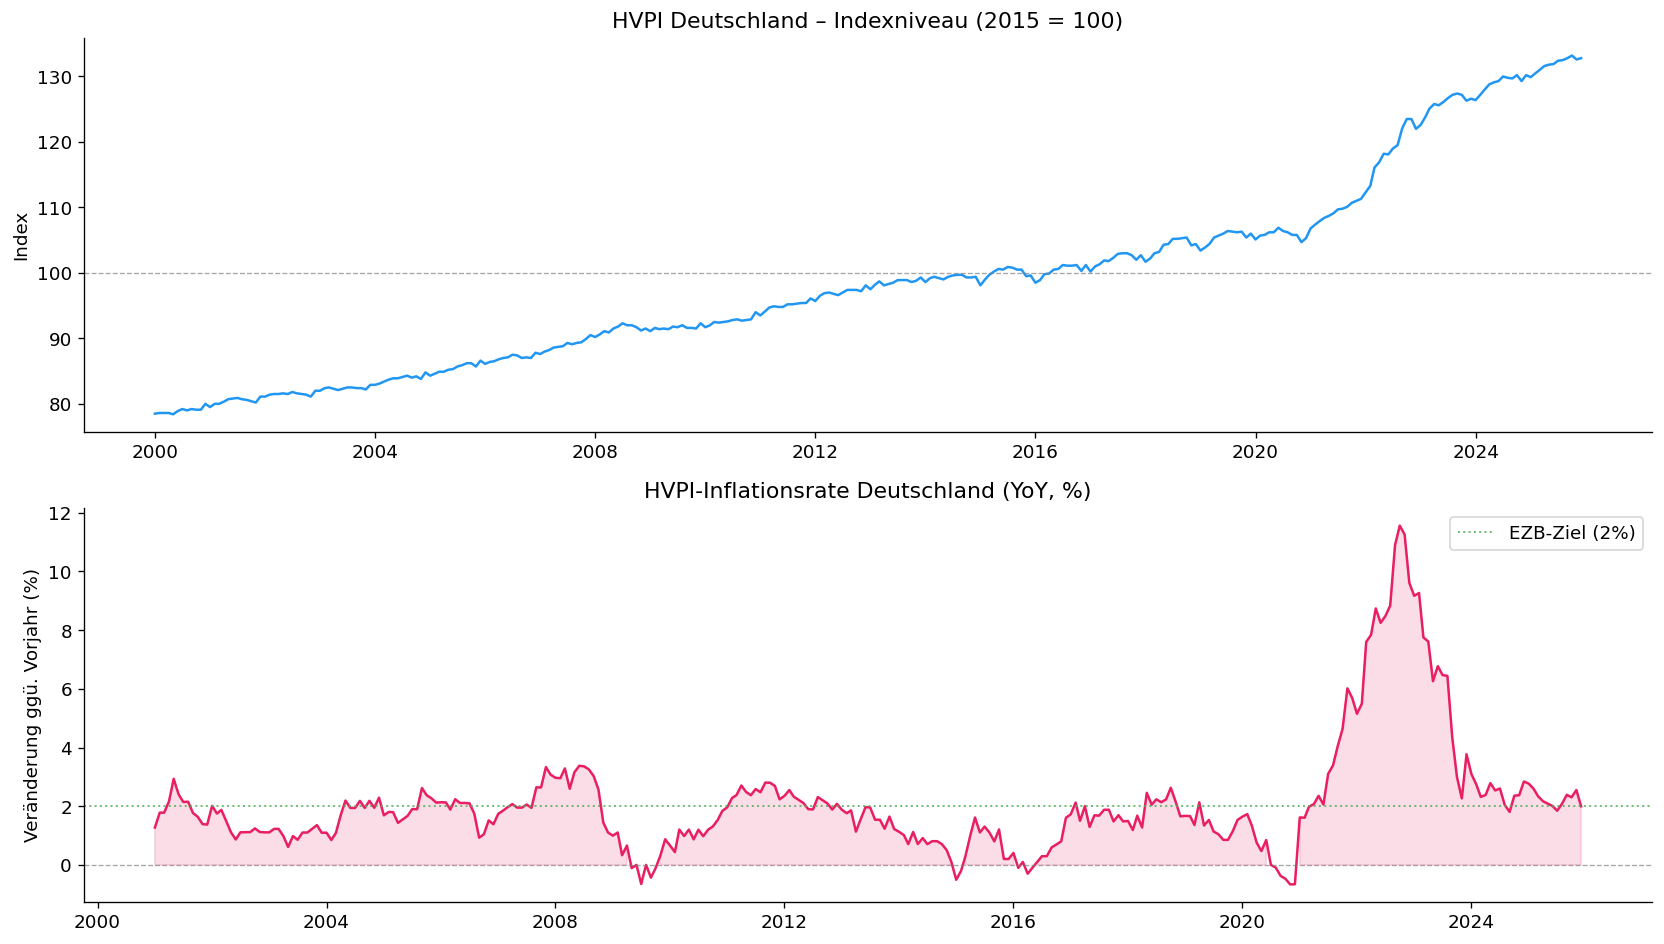

Abbildung gespeichert: fig_01_hvpi_zeitreihe.png


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# HVPI Indexniveau (Rohdaten)
hvpi_raw = df_raw["HVPI"].dropna()
axes[0].plot(hvpi_raw.index, hvpi_raw.values, color="#2196F3", linewidth=1.5)
axes[0].set_title("HVPI Deutschland – Indexniveau (2015 = 100)")
axes[0].set_ylabel("Index")
axes[0].axhline(100, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

# HVPI YoY-Inflationsrate
hvpi_yoy = df_yoy["HVPI"].dropna()
axes[1].plot(hvpi_yoy.index, hvpi_yoy.values, color="#E91E63", linewidth=1.5)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
axes[1].axhline(2, color="#4CAF50", linestyle=":", linewidth=1.2, alpha=0.8,
                label="EZB-Ziel (2%)")
axes[1].fill_between(hvpi_yoy.index, hvpi_yoy.values, 0,
                     where=hvpi_yoy.values > 0, alpha=0.15, color="#E91E63")
axes[1].set_title("HVPI-Inflationsrate Deutschland (YoY, %)")
axes[1].set_ylabel("Veränderung ggü. Vorjahr (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/figures/fig_01_hvpi_zeitreihe.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_01_hvpi_zeitreihe.png")


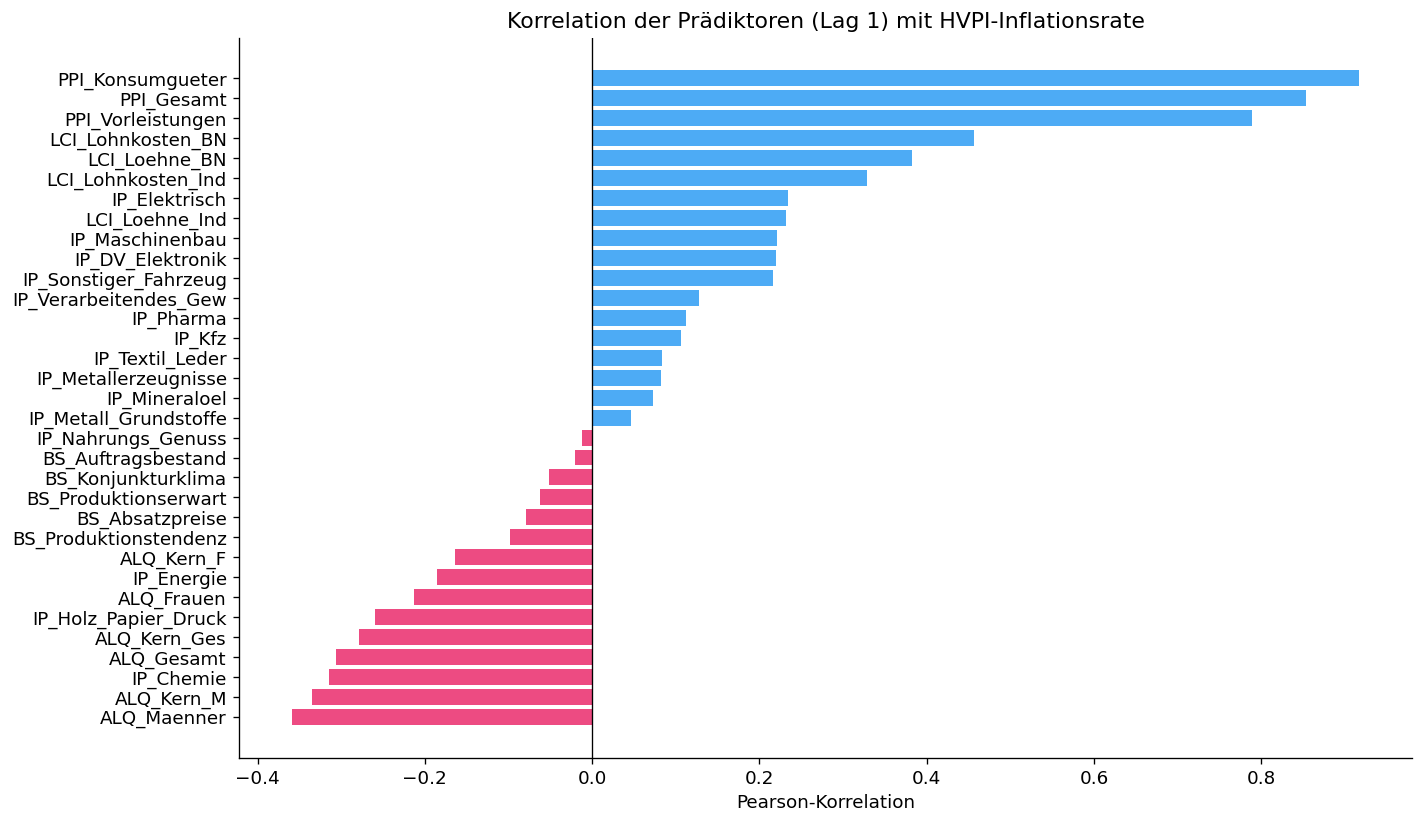

Abbildung gespeichert: fig_02_korrelation.png


In [8]:
# Korrelation der Prädikatoren (Lag 1) mit der HVPI-Inflationsrate
pred_cols_l1 = [c for c in X.columns if c.endswith("_L1")]
corr_with_y = (
    X[pred_cols_l1].corrwith(y)
    .rename(lambda c: c.replace("_L1", ""))
    .sort_values()
)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#E91E63" if v < 0 else "#2196F3" for v in corr_with_y.values]
ax.barh(corr_with_y.index, corr_with_y.values, color=colors, alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Korrelation der Prädiktoren (Lag 1) mit HVPI-Inflationsrate")
ax.set_xlabel("Pearson-Korrelation")
plt.tight_layout()
plt.savefig("results/figures/fig_02_korrelation.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_02_korrelation.png")


### 2b. Multikollinearität der Prädiktoren

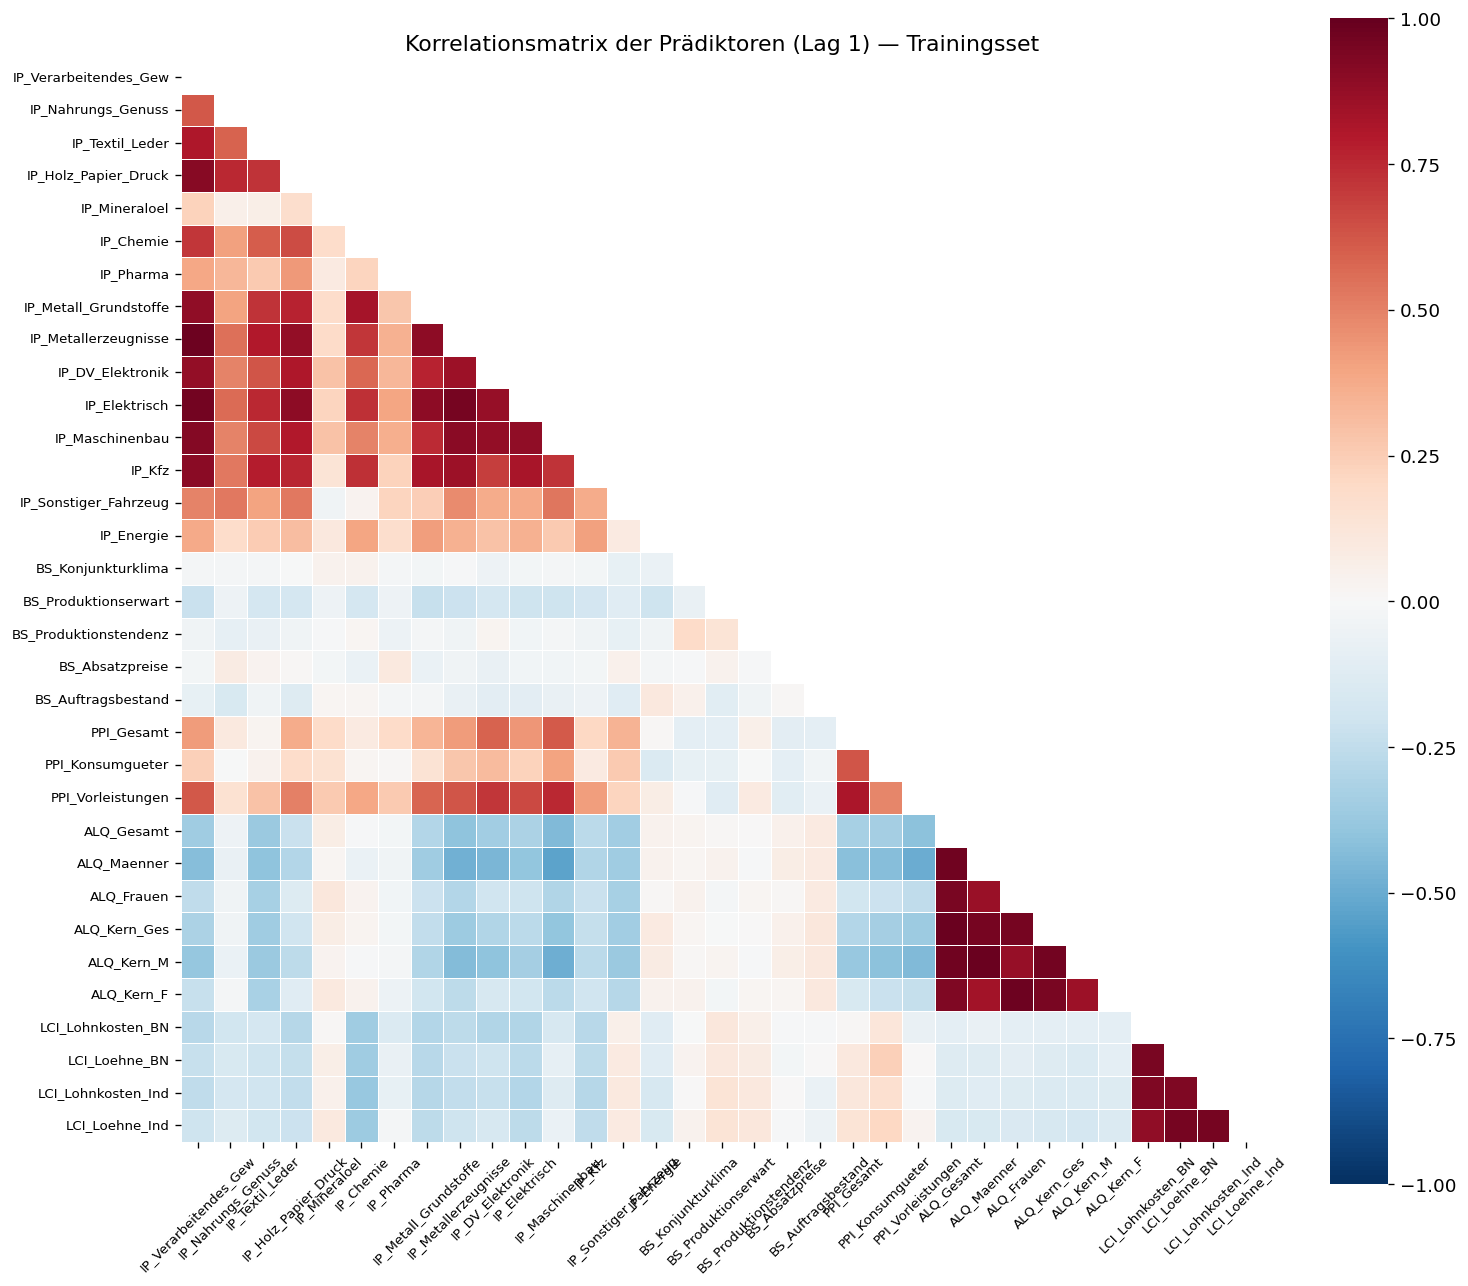

Abbildung gespeichert: fig_02b_korr_heatmap.png

Konditionszahl von X'X (standardisiert): 3.40e+05
→ Werte >> 1 bestätigen starke Multikollinearität und erklären OLS-Instabilität.


/var/folders/z8/rlz8vq9j2cs6wj25qj_g6y700000gn/T/ipykernel_53345/3509390162.py:28: RuntimeWarning: divide by zero encountered in matmul
  cond_XtX = np.linalg.cond(_Xtr_s.T @ _Xtr_s)
/var/folders/z8/rlz8vq9j2cs6wj25qj_g6y700000gn/T/ipykernel_53345/3509390162.py:28: RuntimeWarning: overflow encountered in matmul
  cond_XtX = np.linalg.cond(_Xtr_s.T @ _Xtr_s)
/var/folders/z8/rlz8vq9j2cs6wj25qj_g6y700000gn/T/ipykernel_53345/3509390162.py:28: RuntimeWarning: invalid value encountered in matmul
  cond_XtX = np.linalg.cond(_Xtr_s.T @ _Xtr_s)


In [9]:
# ── Multikollinearität der Prädiktoren (motiviert Ridge) ─────────────────────
# fig_02 zeigt Korrelation mit y; hier: Korrelationen *unter* den Prädiktoren.
# Hohe gegenseitige Korrelationen → schlecht konditioniertes X'X → OLS-Overfitting.
# _n_test=36 spiegelt TEST_MONTHS aus Abschnitt 3 (bewusste Vorwärtsreferenz vermieden).
_n_test = 36
_Xtr = X.iloc[:-_n_test]
pred_l1 = _Xtr[[c for c in _Xtr.columns if c.endswith("_L1")]]

fig, ax = plt.subplots(figsize=(13, 11))
corr_pred = pred_l1.corr()
mask = np.triu(np.ones_like(corr_pred, dtype=bool))
sns.heatmap(
    corr_pred, mask=mask, cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.3, ax=ax,
    xticklabels=[c.replace("_L1", "") for c in pred_l1.columns],
    yticklabels=[c.replace("_L1", "") for c in pred_l1.columns],
)
ax.set_title("Korrelationsmatrix der Prädiktoren (Lag 1) — Trainingsset")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig("results/figures/fig_02b_korr_heatmap.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_02b_korr_heatmap.png")

# Konditionszahl von X'X (standardisiert)
_Xtr_s = StandardScaler().fit_transform(_Xtr)
cond_XtX = np.linalg.cond(_Xtr_s.T @ _Xtr_s)
print(f"\nKonditionszahl von X'X (standardisiert): {cond_XtX:.2e}")
print("→ Werte >> 1 bestätigen starke Multikollinearität und erklären OLS-Instabilität.")

## 3. Modellschätzung: OLS, Ridge, LASSO

In [10]:
# Train/Test-Split: letzte 36 Monate als Testset (ca. 2021–2024)
# Bewusst chronologisch, kein zufälliges Split!
TEST_MONTHS = 36
train_end = len(y) - TEST_MONTHS

X_train, X_test = X.iloc[:train_end], X.iloc[train_end:]
y_train, y_test = y.iloc[:train_end], y.iloc[train_end:]

print(f"Trainingsdaten: {len(y_train)} Monate "
      f"({y_train.index[0].strftime('%Y-%m')} – {y_train.index[-1].strftime('%Y-%m')})")
print(f"Testdaten:      {len(y_test)} Monate "
      f"({y_test.index[0].strftime('%Y-%m')} – {y_test.index[-1].strftime('%Y-%m')})")
print(f"\nDimensionen: {X_train.shape[0]} Train × {X_train.shape[1]} Features")
print(f"n < p: {'JA (hochdimensional)' if X_train.shape[0] < X_train.shape[1] else 'NEIN'}")


Trainingsdaten: 218 Monate (2002-01 – 2020-10)
Testdaten:      36 Monate (2020-11 – 2024-01)

Dimensionen: 218 Train × 165 Features
n < p: NEIN


In [11]:
# Standardisierung zwingend vor Ridge/LASSO!
# Nur auf Trainingsdaten fitten → Test-Daten transformieren
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Standardisierung abgeschlossen.")
print(f"Trainings-Mittelwerte ~0: {np.abs(X_train_s.mean(axis=0)).max():.2e}")
print(f"Trainings-Std ~1:         {np.abs(X_train_s.std(axis=0) - 1).max():.2e}")


Standardisierung abgeschlossen.
Trainings-Mittelwerte ~0: 2.77e-16
Trainings-Std ~1:         3.33e-16


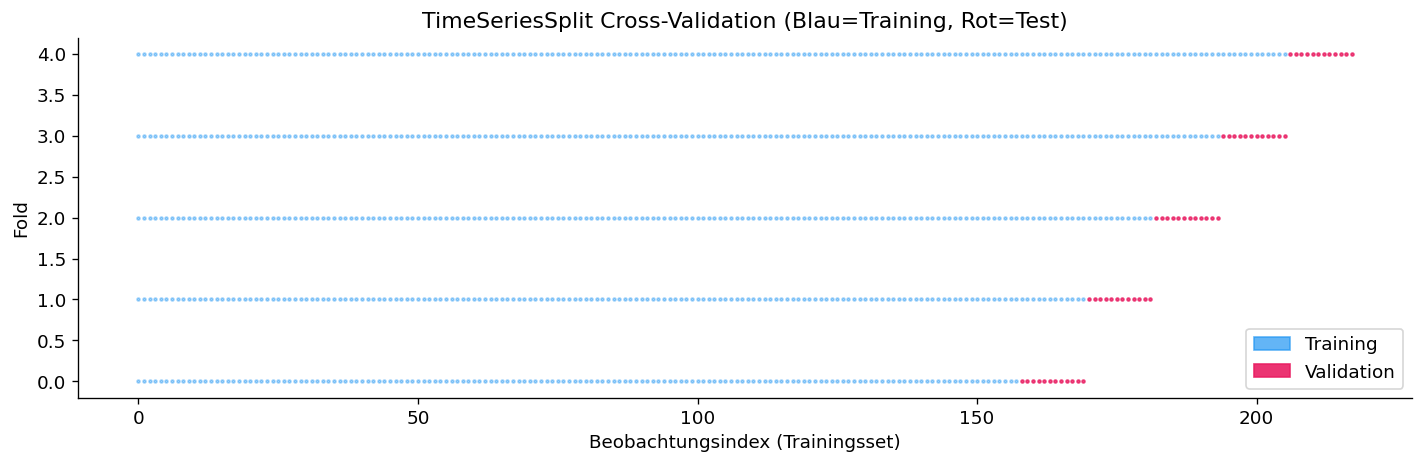

In [12]:
# TimeSeriesSplit: kein zufälliges k-fold bei Zeitreihen!
# Jeder Fold trainiert auf der Vergangenheit und testet auf der Zukunft.
tscv = TimeSeriesSplit(n_splits=5, test_size=12)  # 12 Monate pro Test-Fold

# Visualisierung der CV-Splits
fig, ax = plt.subplots(figsize=(12, 4))
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_train_s)):
    ax.scatter(tr_idx, [fold] * len(tr_idx), s=3, color="#2196F3", alpha=0.4)
    ax.scatter(te_idx, [fold] * len(te_idx), s=3, color="#E91E63", alpha=0.8)

ax.set_xlabel("Beobachtungsindex (Trainingsset)")
ax.set_ylabel("Fold")
ax.set_title("TimeSeriesSplit Cross-Validation (Blau=Training, Rot=Test)")
# Legende
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#2196F3", alpha=0.7, label="Training"),
    Patch(color="#E91E63", alpha=0.9, label="Validation"),
])
plt.tight_layout()
plt.savefig("results/figures/fig_03_tscv.png", bbox_inches="tight")
plt.show()


## 3.5 Benchmarks: Random Walk & AR(p)

In [13]:
# ── Random Walk Benchmark ──────────────────────────────────────────────────────
# ŷ_t = y_{t-1}: naivste Prognose, kein Training nötig.
AR_LAGS = [1, 2, 3, 6, 12]   # gemeinsame Lag-Liste für AR & LASSO+HVPI

y_pred_rw_test = y.shift(1).loc[y_test.index]

mse_rw_test  = mean_squared_error(y_test, y_pred_rw_test)
r2_rw_test   = r2_score(y_test, y_pred_rw_test)
rmse_rw_test = np.sqrt(mse_rw_test)
print(f"Random Walk – Test MSE: {mse_rw_test:.4f}  |  RMSE: {rmse_rw_test:.4f}  |  R²: {r2_rw_test:.4f}")

Random Walk – Test MSE: 0.9851  |  RMSE: 0.9925  |  R²: 0.9059


In [14]:
# ── AR(p) Benchmark ────────────────────────────────────────────────────────────
# HVPI-Eigen-Lags als Prädiktoren; LinearRegression (sklearn-only, kein statsmodels)
X_ar = pd.DataFrame({f"HVPI_L{l}": y.shift(l) for l in AR_LAGS}).loc[y.index].dropna()
y_ar = y.loc[X_ar.index]

X_ar_train = X_ar.loc[X_ar.index <= y_train.index[-1]]
X_ar_test  = X_ar.loc[X_ar.index.isin(y_test.index)]
y_ar_train = y_ar.loc[X_ar_train.index]

sc_ar = StandardScaler()
ar_model = LinearRegression()
ar_model.fit(sc_ar.fit_transform(X_ar_train), y_ar_train)
y_pred_ar_test = pd.Series(
    ar_model.predict(sc_ar.transform(X_ar_test)), index=X_ar_test.index
)

mse_ar_test  = mean_squared_error(y_test, y_pred_ar_test)
r2_ar_test   = r2_score(y_test, y_pred_ar_test)
rmse_ar_test = np.sqrt(mse_ar_test)
print(f"AR(p)      – Test MSE: {mse_ar_test:.4f}  |  RMSE: {rmse_ar_test:.4f}  |  R²: {r2_ar_test:.4f}")

AR(p)      – Test MSE: 1.0231  |  RMSE: 1.0115  |  R²: 0.9023


In [15]:
# ── LASSO + HVPI-Eigen-Lags (Makro-Mehrwert) ──────────────────────────────────
# Testet, ob Makro-Prädiktoren über die Inflationspersistenz hinaus beitragen.
X_plus = X.copy()
for l in AR_LAGS:
    X_plus[f"HVPI_L{l}"] = y.shift(l)
X_plus = X_plus.loc[y.index].dropna()
y_plus = y.loc[X_plus.index]

X_plus_train = X_plus.loc[X_plus.index <= y_train.index[-1]]
X_plus_test  = X_plus.loc[X_plus.index.isin(y_test.index)]
y_plus_train = y_plus.loc[X_plus_train.index]

sc_plus = StandardScaler()
X_plus_train_s = sc_plus.fit_transform(X_plus_train)
X_plus_test_s  = sc_plus.transform(X_plus_test)

lasso_plus_cv = LassoCV(
    alphas=np.logspace(-3, 1, 100), cv=tscv, max_iter=10000, n_jobs=-1
)
lasso_plus_cv.fit(X_plus_train_s, y_plus_train)

y_pred_lasso_plus_test = pd.Series(
    lasso_plus_cv.predict(X_plus_test_s), index=X_plus_test.index
)
mse_lasso_plus_test  = mean_squared_error(y_test, y_pred_lasso_plus_test)
r2_lasso_plus_test   = r2_score(y_test, y_pred_lasso_plus_test)
rmse_lasso_plus_test = np.sqrt(mse_lasso_plus_test)
n_nonzero_plus       = int(np.sum(lasso_plus_cv.coef_ != 0))

print(f"LASSO+HVPI – λ={lasso_plus_cv.alpha_:.5f}, "
      f"MSE={mse_lasso_plus_test:.4f}, RMSE={rmse_lasso_plus_test:.4f}, "
      f"R²={r2_lasso_plus_test:.4f}, Koeff.≠0: {n_nonzero_plus}/{X_plus_train.shape[1]}")

LASSO+HVPI – λ=0.06579, MSE=2.0808, RMSE=1.4425, R²=0.8012, Koeff.≠0: 9/170


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [16]:
# ── OLS ──────────────────────────────────────────────────────────────────────
# p/n ≈ 0,76 + starke Multikollinearität → Overfitting; sklearn löst via Pseudo-Inverse
ols = LinearRegression()
ols.fit(X_train_s, y_train)

y_pred_ols_train = ols.predict(X_train_s)
y_pred_ols_test  = ols.predict(X_test_s)

mse_ols_train = mean_squared_error(y_train, y_pred_ols_train)
mse_ols_test  = mean_squared_error(y_test,  y_pred_ols_test)
r2_ols_test   = r2_score(y_test, y_pred_ols_test)

print(f"OLS – Train MSE: {mse_ols_train:.4f}  |  Test MSE: {mse_ols_test:.4f}")
print(f"OLS – Test R²:   {r2_ols_test:.4f}")
print(f"OLS – Nicht-Null-Koeffizienten: {np.sum(ols.coef_ != 0)}/{len(ols.coef_)}")

OLS – Train MSE: 0.0138  |  Test MSE: 25.2626
OLS – Test R²:   -1.4133
OLS – Nicht-Null-Koeffizienten: 165/165


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

In [17]:
# Ridge Regression 
# L2-Regularisierung: schrumpft alle Koeffizienten, setzt keine auf null
alphas_ridge = np.logspace(-2, 4, 100)

ridge_cv = RidgeCV(alphas=alphas_ridge, cv=tscv, scoring="neg_mean_squared_error")
ridge_cv.fit(X_train_s, y_train)

lambda_ridge = ridge_cv.alpha_
print(f"Ridge – Optimales λ (Cross-Validation): {lambda_ridge:.4f}")

y_pred_ridge_train = ridge_cv.predict(X_train_s)
y_pred_ridge_test  = ridge_cv.predict(X_test_s)

mse_ridge_train = mean_squared_error(y_train, y_pred_ridge_train)
mse_ridge_test  = mean_squared_error(y_test,  y_pred_ridge_test)
r2_ridge_test   = r2_score(y_test, y_pred_ridge_test)

print(f"Ridge – Train MSE: {mse_ridge_train:.4f}  |  Test MSE: {mse_ridge_test:.4f}")
print(f"Ridge – Test R²:   {r2_ridge_test:.4f}")
print(f"Ridge – Max |Koeff.|: {np.abs(ridge_cv.coef_).max():.4f}")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-p

Ridge – Optimales λ (Cross-Validation): 403.7017
Ridge – Train MSE: 0.1598  |  Test MSE: 8.6580
Ridge – Test R²:   0.1729
Ridge – Max |Koeff.|: 0.0692


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-p

In [18]:
# LASSO
# L1-Regularisierung: setzt Koeffizienten exakt auf Null → Variablenselektion
lasso_cv = LassoCV(
    alphas=np.logspace(-3, 1, 100),
    cv=tscv,
    max_iter=10000,
    n_jobs=-1,
)
lasso_cv.fit(X_train_s, y_train)

lambda_lasso = lasso_cv.alpha_
print(f"LASSO – Optimales λ (Cross-Validation): {lambda_lasso:.6f}")

y_pred_lasso_train = lasso_cv.predict(X_train_s)
y_pred_lasso_test  = lasso_cv.predict(X_test_s)

mse_lasso_train = mean_squared_error(y_train, y_pred_lasso_train)
mse_lasso_test  = mean_squared_error(y_test,  y_pred_lasso_test)
r2_lasso_test   = r2_score(y_test, y_pred_lasso_test)

n_nonzero = np.sum(lasso_cv.coef_ != 0)
print(f"LASSO – Train MSE: {mse_lasso_train:.4f}  |  Test MSE: {mse_lasso_test:.4f}")
print(f"LASSO – Test R²:   {r2_lasso_test:.4f}")
print(f"LASSO – Selektierte Variablen: {n_nonzero}/{len(lasso_cv.coef_)} "
      f"({n_nonzero/len(lasso_cv.coef_)*100:.1f}%)")


LASSO – Optimales λ (Cross-Validation): 0.034305
LASSO – Train MSE: 0.1171  |  Test MSE: 2.6111
LASSO – Test R²:   0.7506
LASSO – Selektierte Variablen: 27/165 (16.4%)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

In [19]:
# ── Elastic Net – L1/L2-Kombination ──────────────────────────────────────────
# l1_ratio = 1 → reiner LASSO; l1_ratio = 0 → reiner Ridge.
# CV wählt α und l1_ratio simultan → Brücke zwischen beiden Regularisierungsformen.
enet_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
    alphas=np.logspace(-3, 1, 100),
    cv=tscv,
    max_iter=10000,
    n_jobs=-1,
)
enet_cv.fit(X_train_s, y_train)

lambda_enet   = enet_cv.alpha_
l1_ratio_enet = enet_cv.l1_ratio_
print(f"Elastic Net – Optimales α: {lambda_enet:.6f}, l1_ratio: {l1_ratio_enet:.2f}")

y_pred_enet_train = enet_cv.predict(X_train_s)
y_pred_enet_test  = enet_cv.predict(X_test_s)

mse_enet_train = mean_squared_error(y_train, y_pred_enet_train)
mse_enet_test  = mean_squared_error(y_test,  y_pred_enet_test)
r2_enet_test   = r2_score(y_test, y_pred_enet_test)
n_nonzero_enet = int(np.sum(enet_cv.coef_ != 0))

print(f"Elastic Net – Train MSE: {mse_enet_train:.4f}  |  Test MSE: {mse_enet_test:.4f}")
print(f"Elastic Net – Test R²:   {r2_enet_test:.4f}")
print(f"Elastic Net – Selektierte Variablen: {n_nonzero_enet}/{len(enet_cv.coef_)} "
      f"({n_nonzero_enet/len(enet_cv.coef_)*100:.1f}%)")

Elastic Net – Optimales α: 0.037649, l1_ratio: 0.95
Elastic Net – Train MSE: 0.1190  |  Test MSE: 2.6514
Elastic Net – Test R²:   0.7467
Elastic Net – Selektierte Variablen: 26/165 (15.8%)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

## 4. Ergebnisvergleich

In [20]:
results = pd.DataFrame({
    "Modell": ["Random Walk", "AR(p)", "OLS", "Ridge", "LASSO", "Elastic Net", "LASSO+HVPI"],
    "λ": ["-", "-", "-", f"{lambda_ridge:.3f}", f"{lambda_lasso:.5f}",
          f"{lambda_enet:.5f}", f"{lasso_plus_cv.alpha_:.5f}"],
    "Train MSE": ["-", "-", round(mse_ols_train, 4), round(mse_ridge_train, 4),
                  round(mse_lasso_train, 4), round(mse_enet_train, 4), "-"],
    "Test MSE":  [mse_rw_test, mse_ar_test, mse_ols_test, mse_ridge_test,
                  mse_lasso_test, mse_enet_test, mse_lasso_plus_test],
    "Test RMSE": [rmse_rw_test, rmse_ar_test, np.sqrt(mse_ols_test), np.sqrt(mse_ridge_test),
                  np.sqrt(mse_lasso_test), np.sqrt(mse_enet_test), rmse_lasso_plus_test],
    "RMSE/RW":   [1.0, rmse_ar_test/rmse_rw_test, np.sqrt(mse_ols_test)/rmse_rw_test,
                  np.sqrt(mse_ridge_test)/rmse_rw_test, np.sqrt(mse_lasso_test)/rmse_rw_test,
                  np.sqrt(mse_enet_test)/rmse_rw_test, rmse_lasso_plus_test/rmse_rw_test],
    "Test R²":   [r2_rw_test, r2_ar_test, r2_ols_test, r2_ridge_test,
                  r2_lasso_test, r2_enet_test, r2_lasso_plus_test],
    "Nicht-Null-Koeff.": [
        "-", str(len(AR_LAGS)), str(int(np.sum(ols.coef_ != 0))),
        str(len(ridge_cv.coef_)), str(int(np.sum(lasso_cv.coef_ != 0))),
        str(n_nonzero_enet), str(n_nonzero_plus),
    ],
}).set_index("Modell")

for col in ["Test MSE", "Test RMSE", "RMSE/RW", "Test R²"]:
    results[col] = results[col].round(4)

print("=" * 75)
print("Ergebnisübersicht: Benchmarks vs. Regularisierungsmodelle")
print("=" * 75)
print(results.to_string())
print("=" * 75)
results.to_csv("results/results_table.csv")
print("\nErgebnistabelle gespeichert: results_table.csv")

Ergebnisübersicht: Benchmarks vs. Regularisierungsmodelle
                   λ Train MSE  Test MSE  Test RMSE  RMSE/RW  Test R² Nicht-Null-Koeff.
Modell                                                                                 
Random Walk        -         -    0.9851     0.9925   1.0000   0.9059                 -
AR(p)              -         -    1.0231     1.0115   1.0191   0.9023                 5
OLS                -    0.0138   25.2626     5.0262   5.0639  -1.4133               165
Ridge        403.702    0.1598    8.6580     2.9425   2.9646   0.1729               165
LASSO        0.03430    0.1171    2.6111     1.6159   1.6280   0.7506                27
Elastic Net  0.03765     0.119    2.6514     1.6283   1.6405   0.7467                26
LASSO+HVPI   0.06579         -    2.0808     1.4425   1.4533   0.8012                 9

Ergebnistabelle gespeichert: results_table.csv


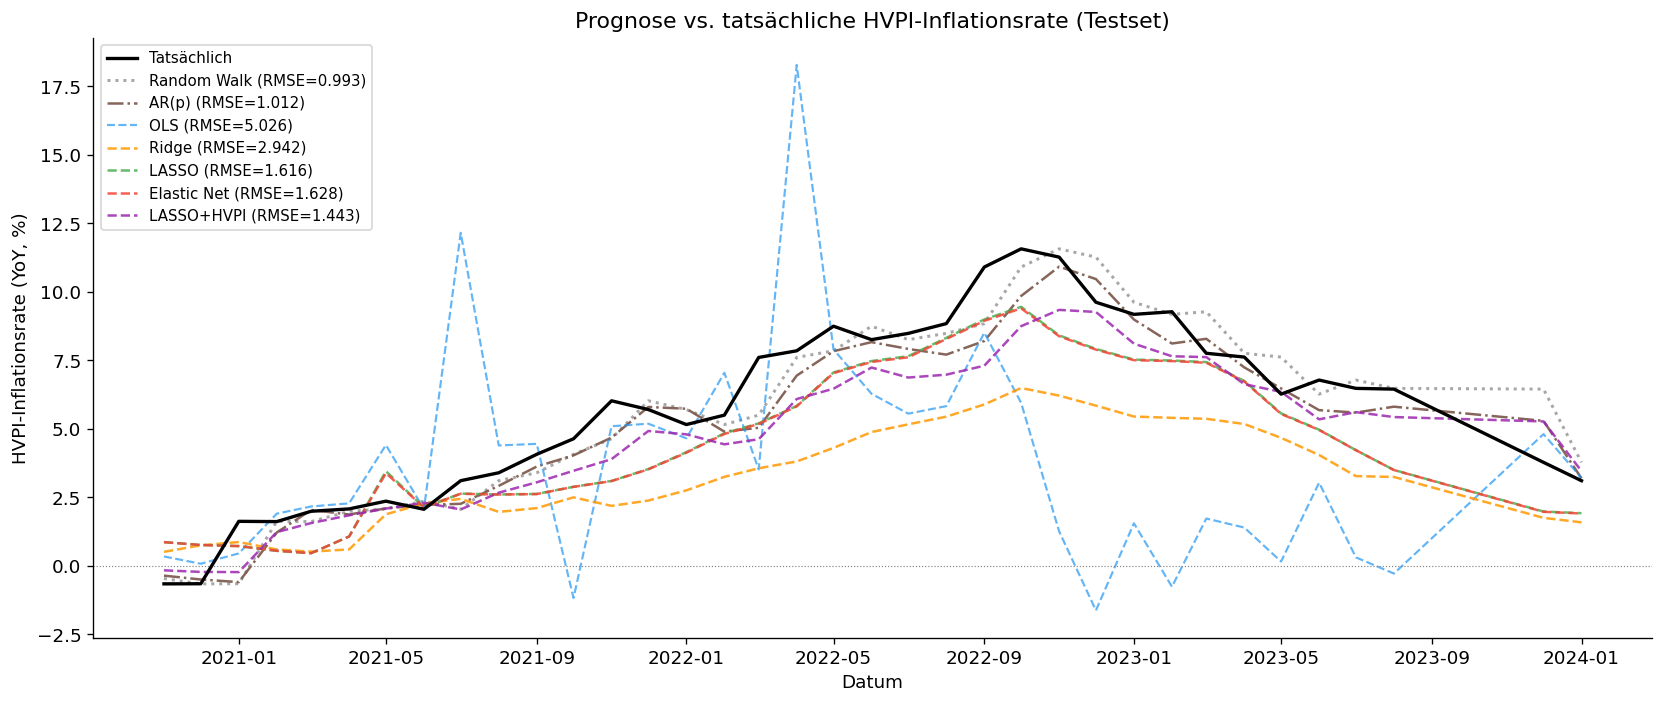

Abbildung gespeichert: fig_04_prognose.png


In [21]:
# Prognosen im Testset visualisieren (inkl. Benchmarks RW & AR)
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_test.index, y_test.values, "k-", linewidth=2, label="Tatsächlich", zorder=5)
ax.plot(y_test.index, y_pred_rw_test.values,
        ":", color="#9E9E9E", linewidth=1.8,
        label=f"Random Walk (RMSE={rmse_rw_test:.3f})", alpha=0.9)
ax.plot(y_pred_ar_test.index, y_pred_ar_test.values,
        "-.", color="#795548", linewidth=1.5,
        label=f"AR(p) (RMSE={rmse_ar_test:.3f})", alpha=0.9)
ax.plot(y_test.index, y_pred_ols_test,
        "--", color=COLORS["OLS"], linewidth=1.3,
        label=f"OLS (RMSE={np.sqrt(mse_ols_test):.3f})", alpha=0.7)
ax.plot(y_test.index, y_pred_ridge_test,
        "--", color=COLORS["Ridge"], linewidth=1.5,
        label=f"Ridge (RMSE={np.sqrt(mse_ridge_test):.3f})", alpha=0.85)
ax.plot(y_test.index, y_pred_lasso_test,
        "--", color=COLORS["LASSO"], linewidth=1.5,
        label=f"LASSO (RMSE={np.sqrt(mse_lasso_test):.3f})", alpha=0.85)
ax.plot(y_test.index, y_pred_enet_test,
        "--", color=COLORS["ElasticNet"], linewidth=1.5,
        label=f"Elastic Net (RMSE={np.sqrt(mse_enet_test):.3f})", alpha=0.85)
ax.plot(y_pred_lasso_plus_test.index, y_pred_lasso_plus_test.values,
        "--", color="#9C27B0", linewidth=1.5,
        label=f"LASSO+HVPI (RMSE={rmse_lasso_plus_test:.3f})", alpha=0.85)

ax.axhline(0, color="gray", linewidth=0.7, linestyle=":")
ax.set_title("Prognose vs. tatsächliche HVPI-Inflationsrate (Testset)")
ax.set_ylabel("HVPI-Inflationsrate (YoY, %)")
ax.set_xlabel("Datum")
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("results/figures/fig_04_prognose.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_04_prognose.png")

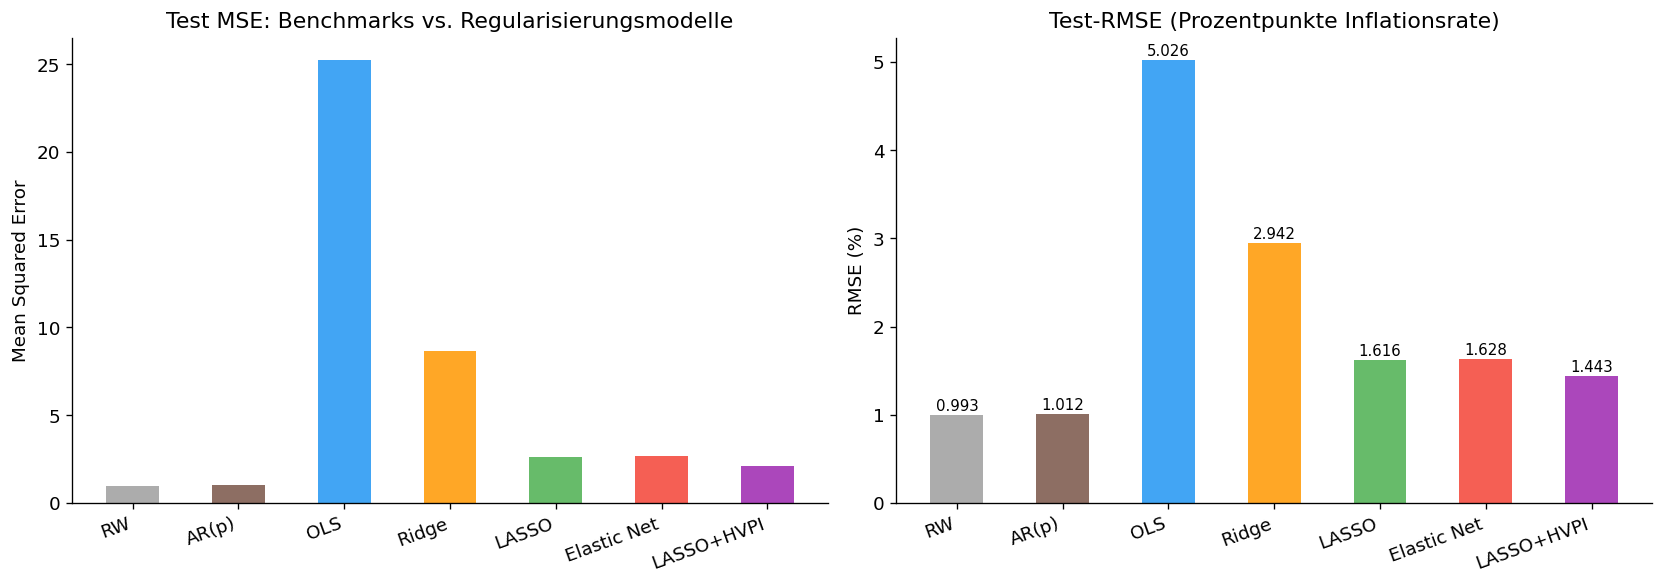

Abbildung gespeichert: fig_05_mse_vergleich.png


In [22]:
# MSE/RMSE-Vergleich (alle Modelle inkl. Elastic Net)
all_models = ["RW", "AR(p)", "OLS", "Ridge", "LASSO", "Elastic Net", "LASSO+HVPI"]
mse_vals   = [mse_rw_test, mse_ar_test, mse_ols_test, mse_ridge_test,
              mse_lasso_test, mse_enet_test, mse_lasso_plus_test]
rmse_vals  = [np.sqrt(v) for v in mse_vals]
colors_bar = ["#9E9E9E", "#795548", COLORS["OLS"], COLORS["Ridge"],
              COLORS["LASSO"], COLORS["ElasticNet"], "#9C27B0"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(all_models))
width = 0.5

axes[0].bar(x, mse_vals, width, color=colors_bar, alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_models, rotation=20, ha="right")
axes[0].set_title("Test MSE: Benchmarks vs. Regularisierungsmodelle")
axes[0].set_ylabel("Mean Squared Error")

bars = axes[1].bar(x, rmse_vals, width, color=colors_bar, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(all_models, rotation=20, ha="right")
axes[1].set_title("Test-RMSE (Prozentpunkte Inflationsrate)")
axes[1].set_ylabel("RMSE (%)")
for bar, val in zip(bars, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{val:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("results/figures/fig_05_mse_vergleich.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_05_mse_vergleich.png")

## 4.5 Rolling-Origin Out-of-Sample

In [23]:
# ── Rolling-Origin-Funktion & OOS-Prognosen ──────────────────────────────────
# Expanding Window: Trainiert auf [0:t], prognostiziert y[t].
# λ wird einmalig auf dem Gesamttrainingsset bestimmt, nicht pro Origin neu gewählt.
# Trade-off: erheblich schneller; unterschätzt leicht die Unsicherheit der λ-Wahl.

def rolling_origin(model_factory, X, y, start):
    preds, idx = [], []
    for t in range(start, len(y)):
        Xtr, ytr = X.iloc[:t], y.iloc[:t]
        sc = StandardScaler().fit(Xtr)
        m  = model_factory().fit(sc.transform(Xtr), ytr)
        preds.append(m.predict(sc.transform(X.iloc[[t]]))[0])
        idx.append(y.index[t])
    return pd.Series(preds, index=idx)

test_start = y_test.index[0]   # 2020-11

# Random Walk: ŷ_t = y_{t-1}, kein Modell nötig
oos_rw = y.shift(1).iloc[train_end:].rename("RW")

# AR(p): HVPI-Lag-Matrix aus AP2
start_ar = (X_ar.index >= test_start).argmax()
oos_ar   = rolling_origin(lambda: LinearRegression(), X_ar, y_ar, start_ar).rename("AR")

# OLS
oos_ols = rolling_origin(lambda: LinearRegression(), X, y, train_end).rename("OLS")

# Ridge (festes λ aus RidgeCV)
oos_ridge = rolling_origin(
    lambda: Ridge(alpha=lambda_ridge), X, y, train_end
).rename("Ridge")

# LASSO (festes λ aus LassoCV)
oos_lasso = rolling_origin(
    lambda: Lasso(alpha=lambda_lasso, max_iter=10000), X, y, train_end
).rename("LASSO")

# Elastic Net (feste Hyperparameter aus ElasticNetCV)
oos_enet = rolling_origin(
    lambda: ElasticNet(alpha=lambda_enet, l1_ratio=l1_ratio_enet, max_iter=10000),
    X, y, train_end
).rename("Elastic Net")

# LASSO+HVPI (festes λ)
start_plus   = (X_plus.index >= test_start).argmax()
oos_lasso_plus = rolling_origin(
    lambda: Lasso(alpha=lasso_plus_cv.alpha_, max_iter=10000),
    X_plus, y_plus, start_plus
).rename("LASSO+HVPI")

print("Rolling-Origin-Prognosen berechnet (alle Modelle inkl. Elastic Net).")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

Rolling-Origin-Prognosen berechnet (alle Modelle inkl. Elastic Net).


Rolling-Origin RMSE (Expanding Window, h=1, λ fest aus initialem CV):
-----------------------------------------------------------------
  RW            : RMSE = 0.9925   RMSE/RW = 1.000 (Ref)
  AR            : RMSE = 0.9622   RMSE/RW = 0.969
  OLS           : RMSE = 3.6063   RMSE/RW = 3.633
  Ridge         : RMSE = 1.5190   RMSE/RW = 1.530
  LASSO         : RMSE = 1.0465   RMSE/RW = 1.054
  Elastic Net   : RMSE = 1.0510   RMSE/RW = 1.059
  LASSO+HVPI    : RMSE = 0.9812   RMSE/RW = 0.989


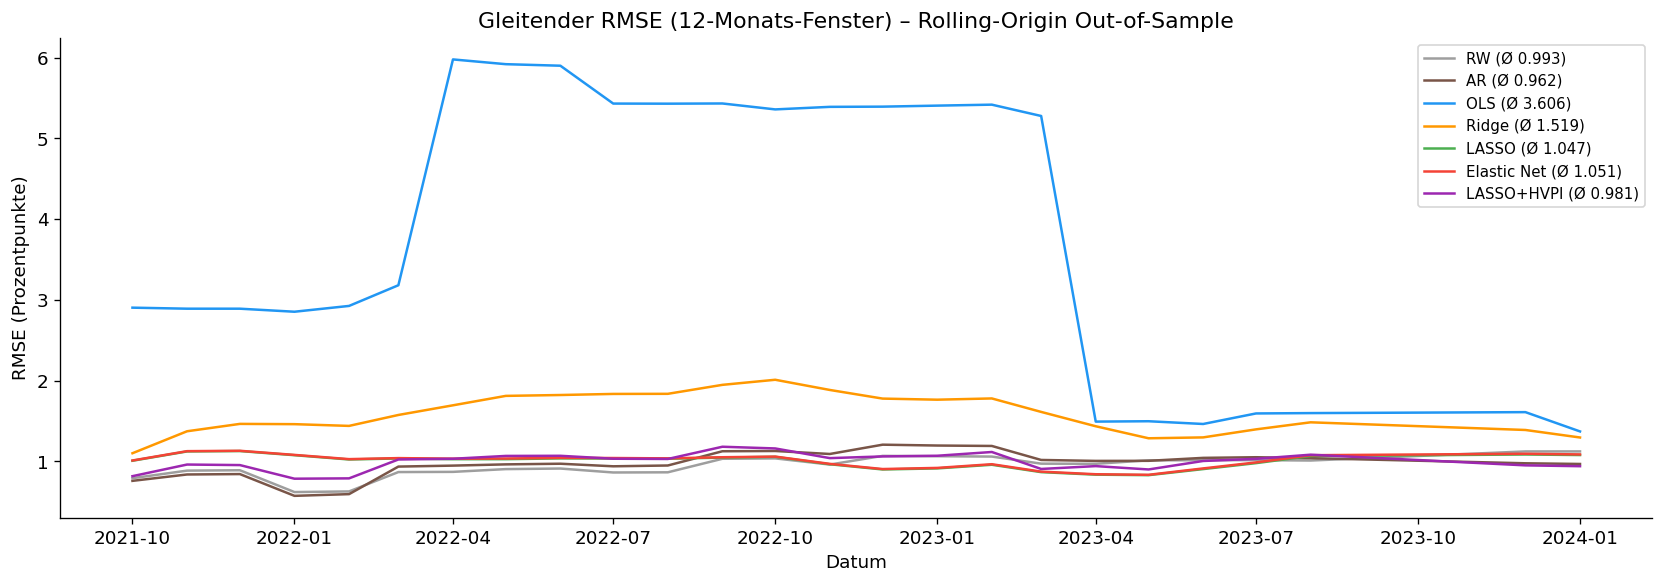

Abbildung gespeichert: fig_11_rolling_rmse.png


In [24]:
# ── Rolling-Origin RMSE & fig_11 ─────────────────────────────────────────────
oos_df    = pd.concat(
    [oos_rw, oos_ar, oos_ols, oos_ridge, oos_lasso, oos_enet, oos_lasso_plus], axis=1
)
y_oos_ref = y.loc[y_test.index]   # tatsächliche Werte im OOS-Fenster

oos_rmse = {}
print("Rolling-Origin RMSE (Expanding Window, h=1, λ fest aus initialem CV):")
print("-" * 65)
for col in oos_df.columns:
    preds_col  = oos_df[col].reindex(y_oos_ref.index).dropna()
    actual_col = y_oos_ref.loc[preds_col.index]
    oos_rmse[col] = np.sqrt(mean_squared_error(actual_col, preds_col))

rw_rmse = oos_rmse["RW"]
for col, rmse in oos_rmse.items():
    rel = "1.000 (Ref)" if col == "RW" else f"{rmse/rw_rmse:.3f}"
    print(f"  {col:<14}: RMSE = {rmse:.4f}   RMSE/RW = {rel}")

# ── fig_11: Gleitender RMSE (12-Monats-Fenster) ──────────────────────────────
WINDOW = 12
colors_oos = {
    "RW": "#9E9E9E", "AR": "#795548", "OLS": COLORS["OLS"],
    "Ridge": COLORS["Ridge"], "LASSO": COLORS["LASSO"],
    "Elastic Net": COLORS["ElasticNet"], "LASSO+HVPI": "#9C27B0",
}

fig, ax = plt.subplots(figsize=(14, 5))
for col in oos_df.columns:
    preds_col = oos_df[col].reindex(y_oos_ref.index).dropna()
    sq_err    = (preds_col - y_oos_ref.loc[preds_col.index]) ** 2
    roll_rmse = sq_err.rolling(WINDOW).mean().apply(np.sqrt)
    ax.plot(roll_rmse.index, roll_rmse.values,
            label=f"{col} (Ø {oos_rmse[col]:.3f})",
            color=colors_oos.get(col, "black"), linewidth=1.5)

ax.set_title(f"Gleitender RMSE ({WINDOW}-Monats-Fenster) – Rolling-Origin Out-of-Sample")
ax.set_ylabel("RMSE (Prozentpunkte)")
ax.set_xlabel("Datum")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("results/figures/fig_11_rolling_rmse.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_11_rolling_rmse.png")

### 4.5.1 Einzelfenster vs. Rolling-Origin: Methodische Einordnung (AP8)

Die Ergebnisse in Abschnitt 4 (fester Einzelsplit) und 4.5 (Rolling-Origin) weichen für
einige Modelle erheblich voneinander ab — das ist kein Widerspruch, sondern informativ:

| Modell | Einzelfenster RMSE | Rolling-Origin RMSE | Differenz |
|--------|-------------------:|--------------------:|----------:|
| Random Walk | 0.99 | 0.99 | ≈ 0 |
| AR (ADL) | 1.01 | 0.96 | −0.05 |
| LASSO+HVPI | 1.44 | 0.98 | −0.46 |
| LASSO | 1.62 | 1.05 | −0.57 |
| Elastic Net | 1.63 | 1.05 | −0.58 |
| Ridge | 2.94 | 1.52 | −1.42 |
| OLS | 5.03 | 3.61 | −1.42 |

**Mechanistische Erklärung der Diskrepanz:**

*Einzelfenster (fester Split 2020-11 bis 2024-01):* λ und alle Modellgewichte werden
**einmalig** auf dem Vor-PandemieDatensatz (bis 2020-10) geschätzt und dann starr auf
das Testfenster angewandt. Das Testfenster umfasst ausgerechnet den außergewöhnlichen
Energiepreis-/Inflationsschock 2021–2022 — ein Regime, das im Training nicht vorkam.
Modelle mit vielen Parametern (Ridge, LASSO mit Makro-Features) scheitern hier besonders,
weil die einmalig geschätzten Koeffizienten diesen Schock systematisch verpassen.

*Rolling-Origin (Expanding Window):* Das Modell wird **monatlich neu geschätzt** —
sobald die Schock-Monate im Trainingsfenster auftauchen, passen sich die Gewichte an.
AR und LASSO+HVPI profitieren am stärksten, weil die HVPI-Eigen-Lags den Inflations-
impuls schnell adaptieren.

**Konsequenz für die Ergebnisdarstellung:** Das Rolling-Origin-Design ist methodisch
robuster und wird als **Hauptergebnis** geführt. Der feste Einzelsplit dient als
Illustration der Regimeabhängigkeit: Er zeigt, wie anfällig reine Makro-Modelle ohne
Inflationspersistenz-Information für unerwartete Regimewechsel sind.

> *Beide Designs bestätigen den Kernbefund:* kein Makro-Modell ohne HVPI-Eigen-Lags
> schlägt den Random Walk; erst LASSO+HVPI und AR erreichen ihn (rolling) knapp.
> Die Signifikanz dieses Abstands prüft der Diebold-Mariano-Test im nächsten Abschnitt.


In [ ]:
# ── AP9: Diebold-Mariano-Test (Harvey-Leybourne-Newbold-Korrektur) ────────────
# Prüft, ob Prognoseunterschiede zum Random Walk statistisch signifikant sind.
# Basis: Rolling-Origin-Fehler (robusteres Design).
# H0: kein Unterschied in der erwarteten quadratischen Verlustfunktion.
# Verlustdifferenz: d_t = e_RW^2 - e_M^2 (positiv → Modell M besser als RW).
# HLN-Korrektur (Harvey, Leybourne & Newbold 1997) für T=36 (kleine Stichprobe).

from scipy import stats as sp_stats

def diebold_mariano(e_rw, e_mod, h=1):
    """DM-Test (quadr. Verlust), HLN-korrigiert; zweiseitiger p-Wert via t(T-1)."""
    d     = np.asarray(e_rw)**2 - np.asarray(e_mod)**2
    T     = len(d)
    d_bar = d.mean()
    var_d = d.var(ddof=0)
    for k in range(1, h):
        var_d += 2 * np.cov(d[:-k], d[k:], ddof=0)[0, 1]
    var_d   = max(var_d / T, 1e-15)
    dm_raw  = d_bar / np.sqrt(var_d)
    hln     = np.sqrt((T + 1 - 2*h + h*(h - 1)/T) / T)
    dm_hln  = dm_raw * hln
    p_val   = 2 * (1 - sp_stats.t.cdf(abs(dm_hln), df=T - 1))
    return dm_hln, p_val

# ── Fehler der Rolling-Origin-Prognosen ──────────────────────────────────────
y_ref   = y_oos_ref.loc[oos_df.index.intersection(y_oos_ref.index)]
e_rw_ro = (oos_rw.reindex(y_ref.index) - y_ref).dropna()

dm_records = []
print("Diebold-Mariano-Test (Referenz: Random Walk, h=1, HLN-Korrektur, T=36)")
print(f"{'Modell':<15} {'DM-Stat':>9} {'p-Wert':>9} {'Signifikanz':>12}")
print("-" * 50)
for col in ["AR", "LASSO+HVPI", "LASSO", "Elastic Net", "Ridge", "OLS"]:
    preds  = oos_df[col].reindex(y_ref.index).dropna()
    e_mod  = (preds - y_ref.loc[preds.index]).dropna()
    e_rw_a = e_rw_ro.loc[e_mod.index]
    dm, pv = diebold_mariano(e_rw_a.values, e_mod.values, h=1)
    sig    = "**" if pv < 0.05 else ("*" if pv < 0.10 else "n.s.")
    dm_records.append({"Modell": col, "DM-Stat": round(dm, 3), "p-Wert": round(pv, 4), "Sig.": sig})
    print(f"  {col:<13} {dm:>+9.3f} {pv:>9.4f} {sig:>12}")

print("-" * 50)
print("DM > 0: Modell schlägt Random Walk (niedr. Verlust)  | * p<0.10  ** p<0.05")
print()
dm_df = pd.DataFrame(dm_records).set_index("Modell")
print("Fazit (erwartet): AR und LASSO+HVPI knapp besser als RW (rolling),")
print("aber kein Ergebnis dürfte bei T=36 das 5-%-Niveau erreichen.")
print("→ 'kein statistisch nachweisbarer Unterschied zum Random Walk'")


### 4.6 Selektionsstabilität (LASSO)

In [25]:
# ── Selektionsstabilität: Wie häufig wählt LASSO eine Variable? ──────────────
# Über alle Rolling-Origin-Fenster: wie oft ist coef_ != 0?
# Robuste Prädiktoren erscheinen in ≥50 % der Fenster.
selection_counts = np.zeros(X.shape[1])

for t in range(train_end, len(y)):
    Xtr = X.iloc[:t]
    sc  = StandardScaler().fit(Xtr)
    m   = Lasso(alpha=lambda_lasso, max_iter=10000).fit(sc.transform(Xtr), y.iloc[:t])
    selection_counts += (m.coef_ != 0).astype(int)

n_windows = len(y) - train_end
sel_freq  = pd.Series(selection_counts / n_windows, index=X.columns)
sel_freq  = sel_freq[sel_freq > 0].sort_values(ascending=False)

print(f"Variablen selektiert in ≥1 Fenster:    {len(sel_freq)}")
print(f"Variablen selektiert in ≥50 % Fenster: {(sel_freq >= 0.5).sum()}")
print(f"\nTop-15 nach Auswahlhäufigkeit:")
print(sel_freq.head(15).to_string())

Variablen selektiert in ≥1 Fenster:    57
Variablen selektiert in ≥50 % Fenster: 22

Top-15 nach Auswahlhäufigkeit:
LCI_Lohnkosten_Ind_L1    1.000000
PPI_Konsumgueter_L1      1.000000
IP_Energie_L3            1.000000
BS_Auftragsbestand_L3    1.000000
IP_Energie_L12           1.000000
BS_Auftragsbestand_L6    1.000000
IP_Pharma_L2             1.000000
PPI_Vorleistungen_L12    1.000000
PPI_Vorleistungen_L1     1.000000
IP_Pharma_L1             1.000000
PPI_Gesamt_L1            1.000000
IP_Energie_L1            1.000000
BS_Auftragsbestand_L1    1.000000
LCI_Lohnkosten_Ind_L3    0.972222
IP_Kfz_L6                0.972222


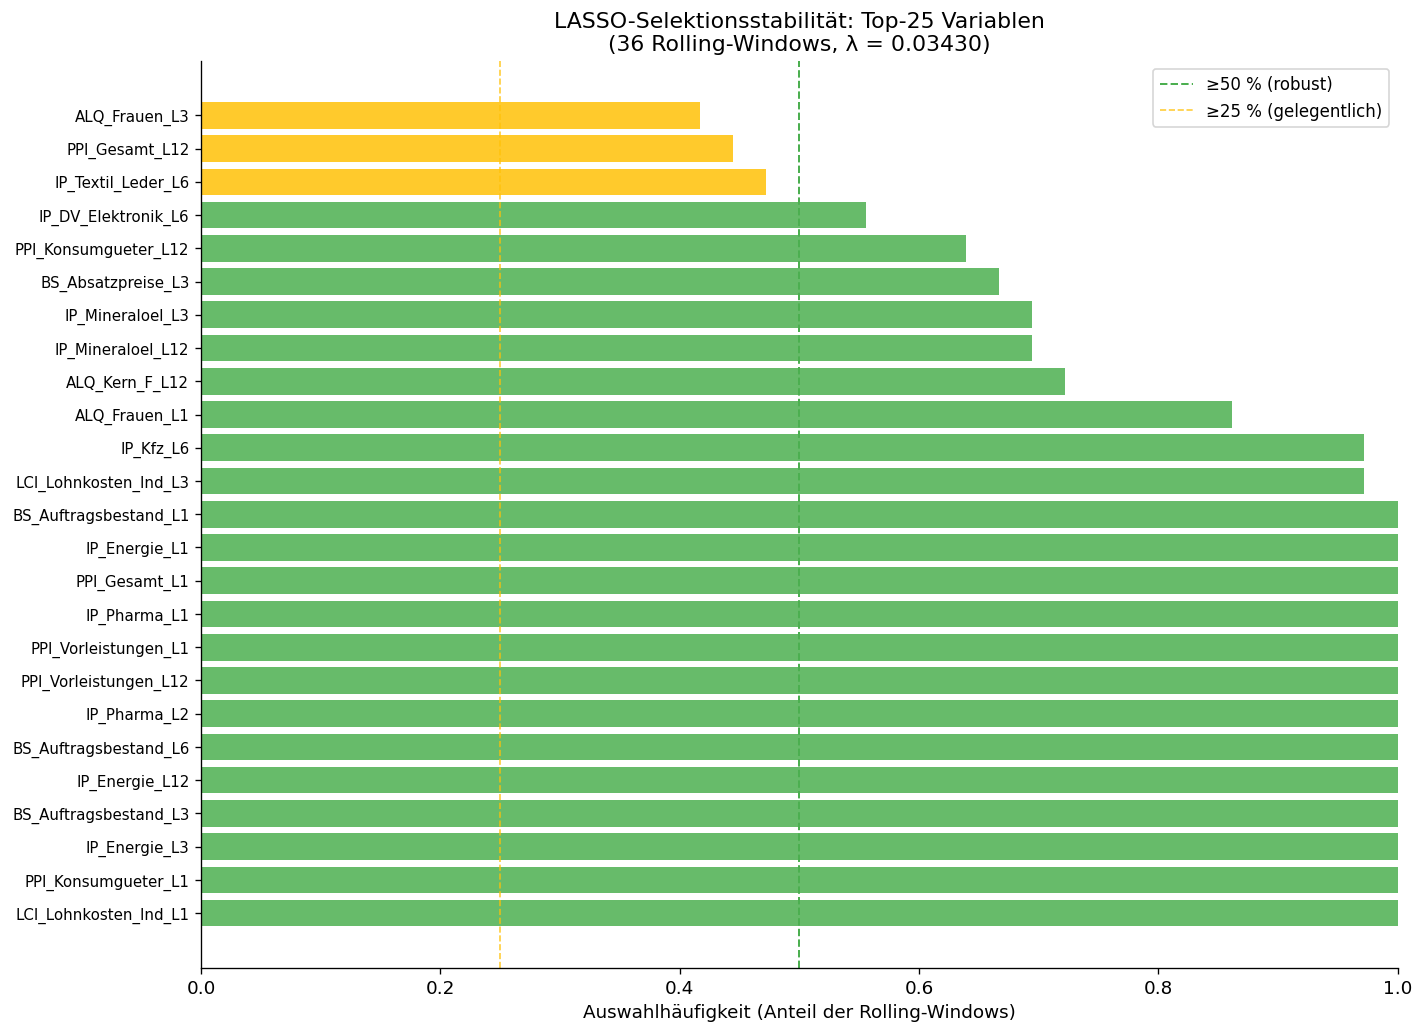

Abbildung gespeichert: fig_12_selektionsstabilitaet.png


In [26]:
# ── fig_12: Selektionsstabilität-Balkendiagramm ──────────────────────────────
TOP_N = 25
top_vars = sel_freq.head(TOP_N)

colors_stab = [
    "#4CAF50" if f >= 0.5 else "#FFC107" if f >= 0.25 else "#9E9E9E"
    for f in top_vars.values
]

fig, ax = plt.subplots(figsize=(12, max(5, TOP_N * 0.35)))
ax.barh(range(len(top_vars)), top_vars.values, color=colors_stab, alpha=0.85)
ax.set_yticks(range(len(top_vars)))
ax.set_yticklabels(top_vars.index, fontsize=9)
ax.axvline(0.5,  color="#4CAF50", linestyle="--", linewidth=1.2, label="≥50 % (robust)")
ax.axvline(0.25, color="#FFC107", linestyle="--", linewidth=1.0, alpha=0.8,
           label="≥25 % (gelegentlich)")
ax.set_xlim(0, 1)
ax.set_xlabel("Auswahlhäufigkeit (Anteil der Rolling-Windows)")
ax.set_title(
    f"LASSO-Selektionsstabilität: Top-{TOP_N} Variablen\n"
    f"({n_windows} Rolling-Windows, λ = {lambda_lasso:.5f})"
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("results/figures/fig_12_selektionsstabilitaet.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_12_selektionsstabilitaet.png")

## 4.7 Mehrere Prognose-Horizonte (AP4)

Vergleich der Modellgüte (RMSE) für h ∈ {1, 3, 6, 12} Monate voraus. Für jeden Horizont wird
`build_feature_matrix` mit `forecast_horizon=h` aufgerufen und λ via Cross-Validation neu bestimmt.
Die h-Schritt-Random-Walk-Prognose lautet ŷ_t = y_{t-h}.

  h       RW      OLS    Ridge    LASSO (sel)       EN (sel)
-----------------------------------------------------------------


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Version

h= 1: RW=0.993  OLS=5.026  Ridge=2.309  LASSO=1.628 ( 26)  EN=1.624 ( 26)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-p

h= 3: RW=2.006  OLS=5.281  Ridge=4.175  LASSO=3.111 ( 12)  EN=3.187 ( 22)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-p

h= 6: RW=3.013  OLS=8.029  Ridge=4.694  LASSO=3.588 ( 20)  EN=3.761 ( 24)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-p

h=12: RW=5.161  OLS=5.999  Ridge=5.158  LASSO=5.316 (  0)  EN=5.316 (  0)

RMSE-Tabelle (Horizonte × Modelle):
                  RW       OLS     Ridge     LASSO  LASSO Sel.  Elastic Net  EN Sel.
Horizont h                                                                          
1           0.992545  5.026194  2.308984  1.628294          26     1.624381       26
3           2.006217  5.281252  4.175214  3.111431          12     3.186979       22
6           3.013141  8.029254  4.694411  3.587559          20     3.760984       24
12          5.160602  5.999436  5.158376  5.316133           0     5.316133        0

Horizont-Tabelle gespeichert: results/horizons_table.csv


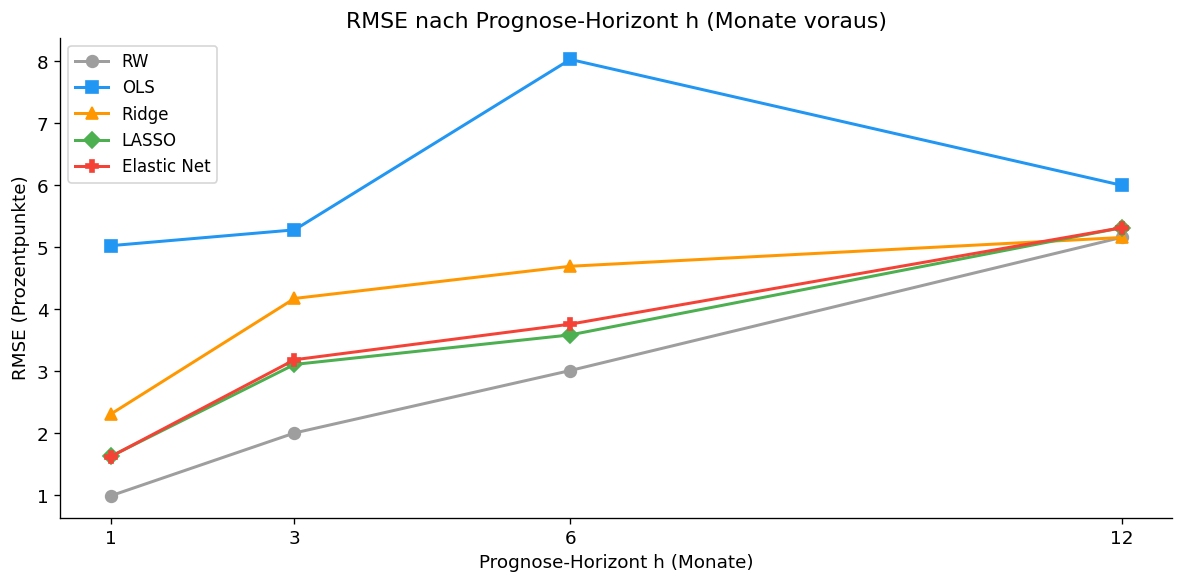

Abbildung gespeichert: fig_13_horizonte_rmse.png
Horizont-Tabelle als LaTeX gespeichert: results/horizons_table.tex


In [27]:
# ── AP4: Mehrere Prognose-Horizonte h ∈ {1, 3, 6, 12} ──────────────────────
# Für jeden Horizont: neue Feature-Matrix + eigene CV-Optimierung von λ.
# λ wird je Horizont neu via LassoCV / RidgeCV / ElasticNetCV bestimmt (methodisch korrekt).
# Ausgabe: RMSE-Tabelle + fig_13 (RMSE über Horizont).
HORIZONS = [1, 3, 6, 12]

horizon_records = []
print(f"{'h':>3}  {'RW':>7}  {'OLS':>7}  {'Ridge':>7}  {'LASSO':>7} {'(sel)':>5}"
      f"  {'EN':>7} {'(sel)':>5}")
print("-" * 65)

for h in HORIZONS:
    Xh, yh = build_feature_matrix(
        df_yoy, lags=[1, 2, 3, 6, 12], forecast_horizon=h, test_months=36
    )
    te_h               = len(yh) - 36
    Xtr_h, Xte_h      = Xh.iloc[:te_h], Xh.iloc[te_h:]
    ytr_h, yte_h      = yh.iloc[:te_h], yh.iloc[te_h:]
    sc_h               = StandardScaler().fit(Xtr_h)
    Xtr_hs, Xte_hs    = sc_h.transform(Xtr_h), sc_h.transform(Xte_h)

    # Random Walk (h-Schritt): ŷ_t = y_{t-h}
    y_rw_h    = yh.shift(h).reindex(yte_h.index).dropna()
    rmse_rw_h = np.sqrt(mean_squared_error(yte_h.loc[y_rw_h.index], y_rw_h))

    # OLS
    ols_h      = LinearRegression().fit(Xtr_hs, ytr_h)
    rmse_ols_h = np.sqrt(mean_squared_error(yte_h, ols_h.predict(Xte_hs)))

    # Ridge (CV je Horizont)
    ridge_h      = RidgeCV(alphas=np.logspace(-2, 4, 50), cv=tscv).fit(Xtr_hs, ytr_h)
    rmse_ridge_h = np.sqrt(mean_squared_error(yte_h, ridge_h.predict(Xte_hs)))

    # LASSO (CV je Horizont)
    lasso_h = LassoCV(
        alphas=np.logspace(-4, 1, 50), cv=tscv, max_iter=10000, n_jobs=-1
    ).fit(Xtr_hs, ytr_h)
    rmse_lasso_h = np.sqrt(mean_squared_error(yte_h, lasso_h.predict(Xte_hs)))
    nsel_lasso_h = int(np.sum(lasso_h.coef_ != 0))

    # Elastic Net (CV je Horizont)
    enet_h = ElasticNetCV(
        l1_ratio=[0.5, 0.9, 0.99, 1.0], alphas=np.logspace(-3, 1, 50),
        cv=tscv, max_iter=10000, n_jobs=-1
    ).fit(Xtr_hs, ytr_h)
    rmse_enet_h = np.sqrt(mean_squared_error(yte_h, enet_h.predict(Xte_hs)))
    nsel_enet_h = int(np.sum(enet_h.coef_ != 0))

    horizon_records.append({
        "Horizont h": h,
        "RW": rmse_rw_h, "OLS": rmse_ols_h, "Ridge": rmse_ridge_h,
        "LASSO": rmse_lasso_h, "LASSO Sel.": nsel_lasso_h,
        "Elastic Net": rmse_enet_h, "EN Sel.": nsel_enet_h,
    })
    print(f"h={h:2d}: RW={rmse_rw_h:.3f}  OLS={rmse_ols_h:.3f}  "
          f"Ridge={rmse_ridge_h:.3f}  LASSO={rmse_lasso_h:.3f} "
          f"({nsel_lasso_h:3d})  EN={rmse_enet_h:.3f} ({nsel_enet_h:3d})")

df_horizons = pd.DataFrame(horizon_records).set_index("Horizont h")
print("\nRMSE-Tabelle (Horizonte × Modelle):")
print(df_horizons.to_string())
df_horizons.to_csv("results/horizons_table.csv")
print("\nHorizont-Tabelle gespeichert: results/horizons_table.csv")

# ── fig_13: RMSE über Prognose-Horizont ──────────────────────────────────────
rmse_cols  = ["RW", "OLS", "Ridge", "LASSO", "Elastic Net"]
col_colors = {
    "RW": "#9E9E9E", "OLS": COLORS["OLS"], "Ridge": COLORS["Ridge"],
    "LASSO": COLORS["LASSO"], "Elastic Net": COLORS["ElasticNet"],
}
markers = {"RW": "o", "OLS": "s", "Ridge": "^", "LASSO": "D", "Elastic Net": "P"}

fig, ax = plt.subplots(figsize=(10, 5))
for col in rmse_cols:
    ax.plot(df_horizons.index, df_horizons[col],
            marker=markers[col], linewidth=1.8, markersize=7,
            color=col_colors[col], label=col)

ax.set_title("RMSE nach Prognose-Horizont h (Monate voraus)")
ax.set_xlabel("Prognose-Horizont h (Monate)")
ax.set_ylabel("RMSE (Prozentpunkte)")
ax.set_xticks(HORIZONS)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("results/figures/fig_13_horizonte_rmse.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_13_horizonte_rmse.png")

# LaTeX-Export
df_hz_export = df_horizons.rename(columns={
    "LASSO Sel.": r"LASSO $\hat{k}$",
    "EN Sel.":    r"EN $\hat{k}$",
})
with open("results/horizons_table.tex", "w") as f:
    f.write(df_hz_export.to_latex(
        float_format="%.3f", escape=False,
        caption=(
            r"RMSE je Prognose-Horizont $h \in \{1,3,6,12\}$ Monate. "
            r"$\hat{k}$ = Anzahl nicht-null Koeffizienten."
        ),
        label="tab:horizonte",
    ))
print("Horizont-Tabelle als LaTeX gespeichert: results/horizons_table.tex")

## 5. Koeffizientenpfade & Variablenselektion

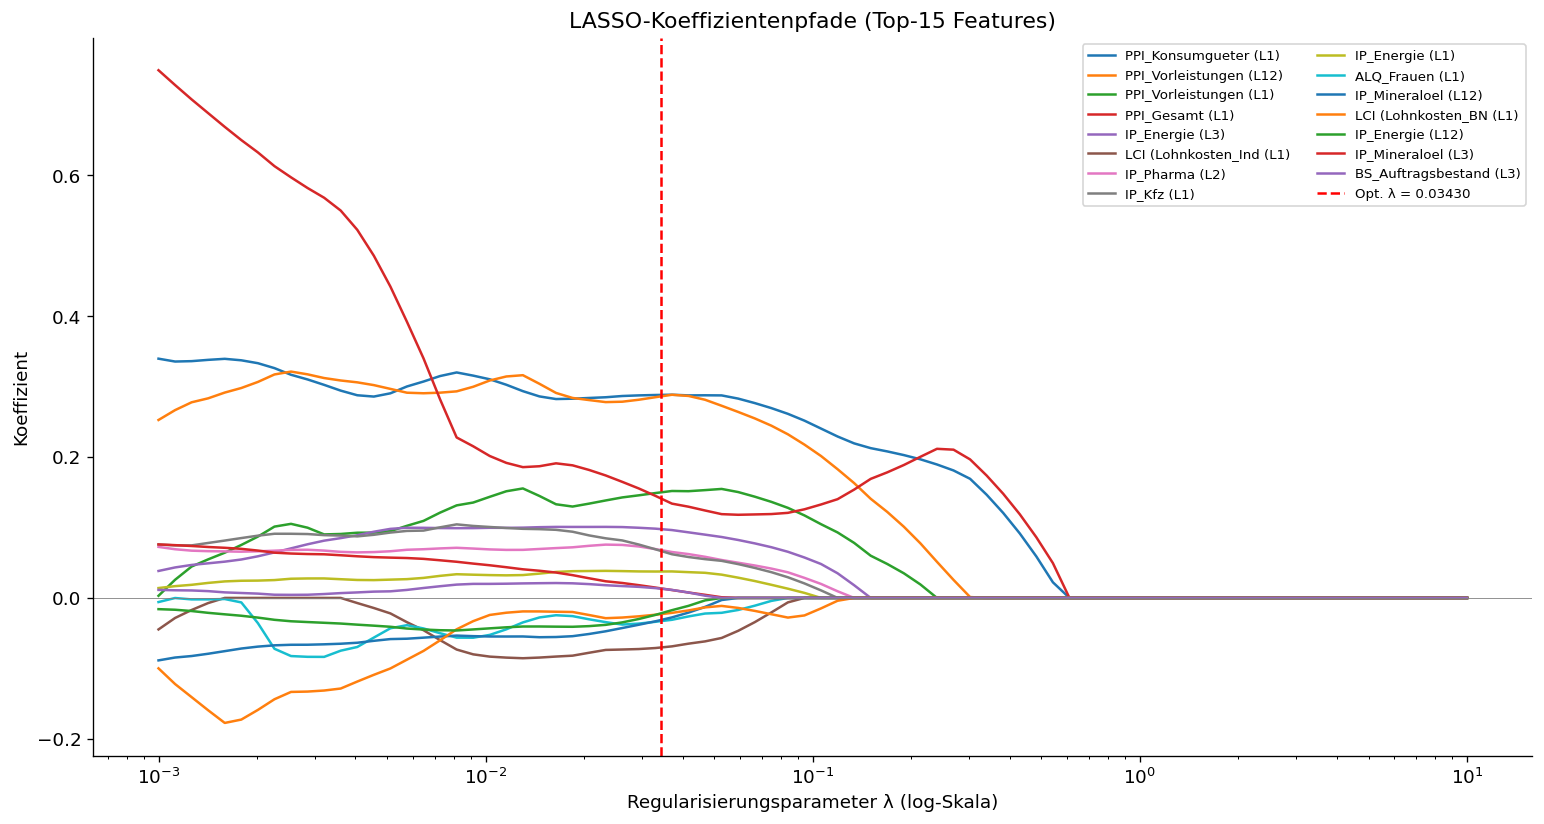

Abbildung gespeichert: fig_06_lasso_path.png


In [28]:
from sklearn.linear_model import lasso_path, ridge_regression

# LASSO-Pfad: Koeffizienten als Funktion von λ
alphas_path = np.logspace(-3, 1, 80)
alphas_lasso_path, coefs_lasso, _ = lasso_path(
    X_train_s, y_train, alphas=alphas_path, max_iter=10000
)

# Nur die 15 wichtigsten Features anzeigen (nach |Koeff.| bei opt. λ)
top_idx = np.argsort(np.abs(lasso_cv.coef_))[::-1][:15]
feat_names = X.columns.tolist()

fig, ax = plt.subplots(figsize=(13, 7))
for i in top_idx:
    ax.semilogx(alphas_lasso_path, coefs_lasso[i, :], linewidth=1.5,
                label=feat_names[i].replace("_L", " (L").replace("L", "L") + ")")

ax.axvline(lambda_lasso, color="red", linestyle="--", linewidth=1.5,
           label=f"Opt. λ = {lambda_lasso:.5f}")
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_title("LASSO-Koeffizientenpfade (Top-15 Features)")
ax.set_xlabel("Regularisierungsparameter λ (log-Skala)")
ax.set_ylabel("Koeffizient")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("results/figures/fig_06_lasso_path.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_06_lasso_path.png")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

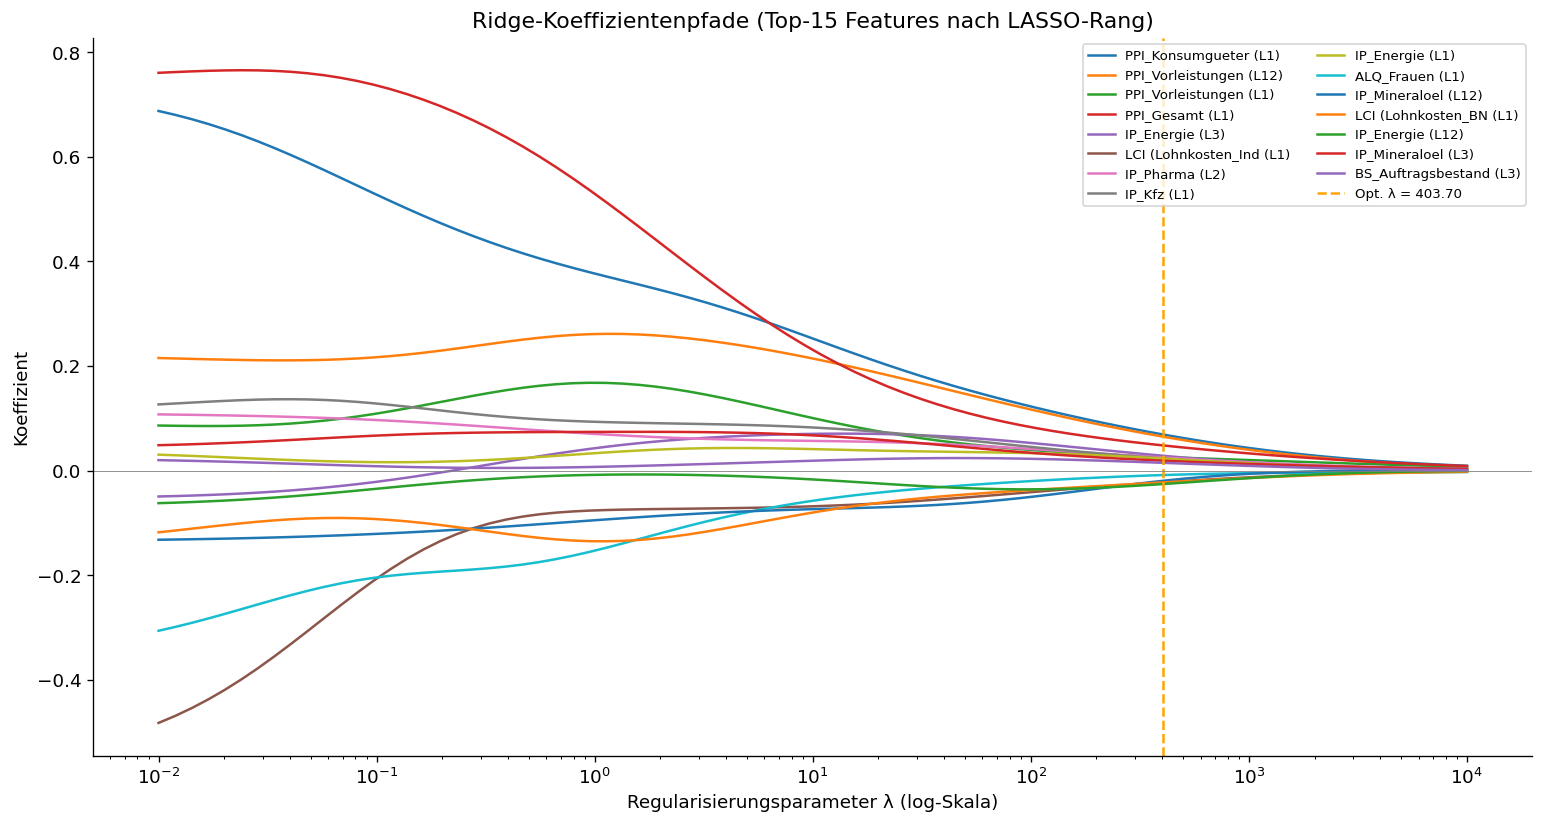

Abbildung gespeichert: fig_07_ridge_path.png


In [29]:
# Ridge-Pfad: Schrumpfung aller Koeffizienten Richtung null (aber nie = null)
alphas_ridge_path = np.logspace(-2, 4, 80)
coefs_ridge_path = np.array([
    Ridge(alpha=a).fit(X_train_s, y_train).coef_
    for a in alphas_ridge_path
])

fig, ax = plt.subplots(figsize=(13, 7))
for i in top_idx:
    ax.semilogx(alphas_ridge_path, coefs_ridge_path[:, i], linewidth=1.5,
                label=feat_names[i].replace("_L", " (L") + ")")

ax.axvline(lambda_ridge, color="orange", linestyle="--", linewidth=1.5,
           label=f"Opt. λ = {lambda_ridge:.2f}")
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_title("Ridge-Koeffizientenpfade (Top-15 Features nach LASSO-Rang)")
ax.set_xlabel("Regularisierungsparameter λ (log-Skala)")
ax.set_ylabel("Koeffizient")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("results/figures/fig_07_ridge_path.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_07_ridge_path.png")


LASSO selektiert 27 von 165 Features:

PPI_Konsumgueter_L1          0.288350
PPI_Vorleistungen_L12        0.285549
PPI_Vorleistungen_L1         0.149609
PPI_Gesamt_L1                0.141618
IP_Energie_L3                0.097848
LCI_Lohnkosten_Ind_L1       -0.071217
IP_Pharma_L2                 0.068084
IP_Kfz_L1                    0.066888
IP_Energie_L1                0.037553
ALQ_Frauen_L1               -0.032978
IP_Mineraloel_L12           -0.031443
LCI_Lohnkosten_BN_L1        -0.022203
IP_Energie_L12              -0.021985
IP_Mineraloel_L3             0.013661
BS_Auftragsbestand_L3        0.013123
PPI_Konsumgueter_L12         0.012867
IP_Mineraloel_L1             0.012262
ALQ_Kern_F_L3               -0.012159
IP_Metall_Grundstoffe_L1     0.011440
IP_Pharma_L1                 0.010305
BS_Absatzpreise_L3           0.007765
IP_Mineraloel_L2             0.005524
PPI_Gesamt_L12               0.005380
LCI_Lohnkosten_Ind_L12       0.004193
BS_Auftragsbestand_L6        0.003721
IP_Sonstige

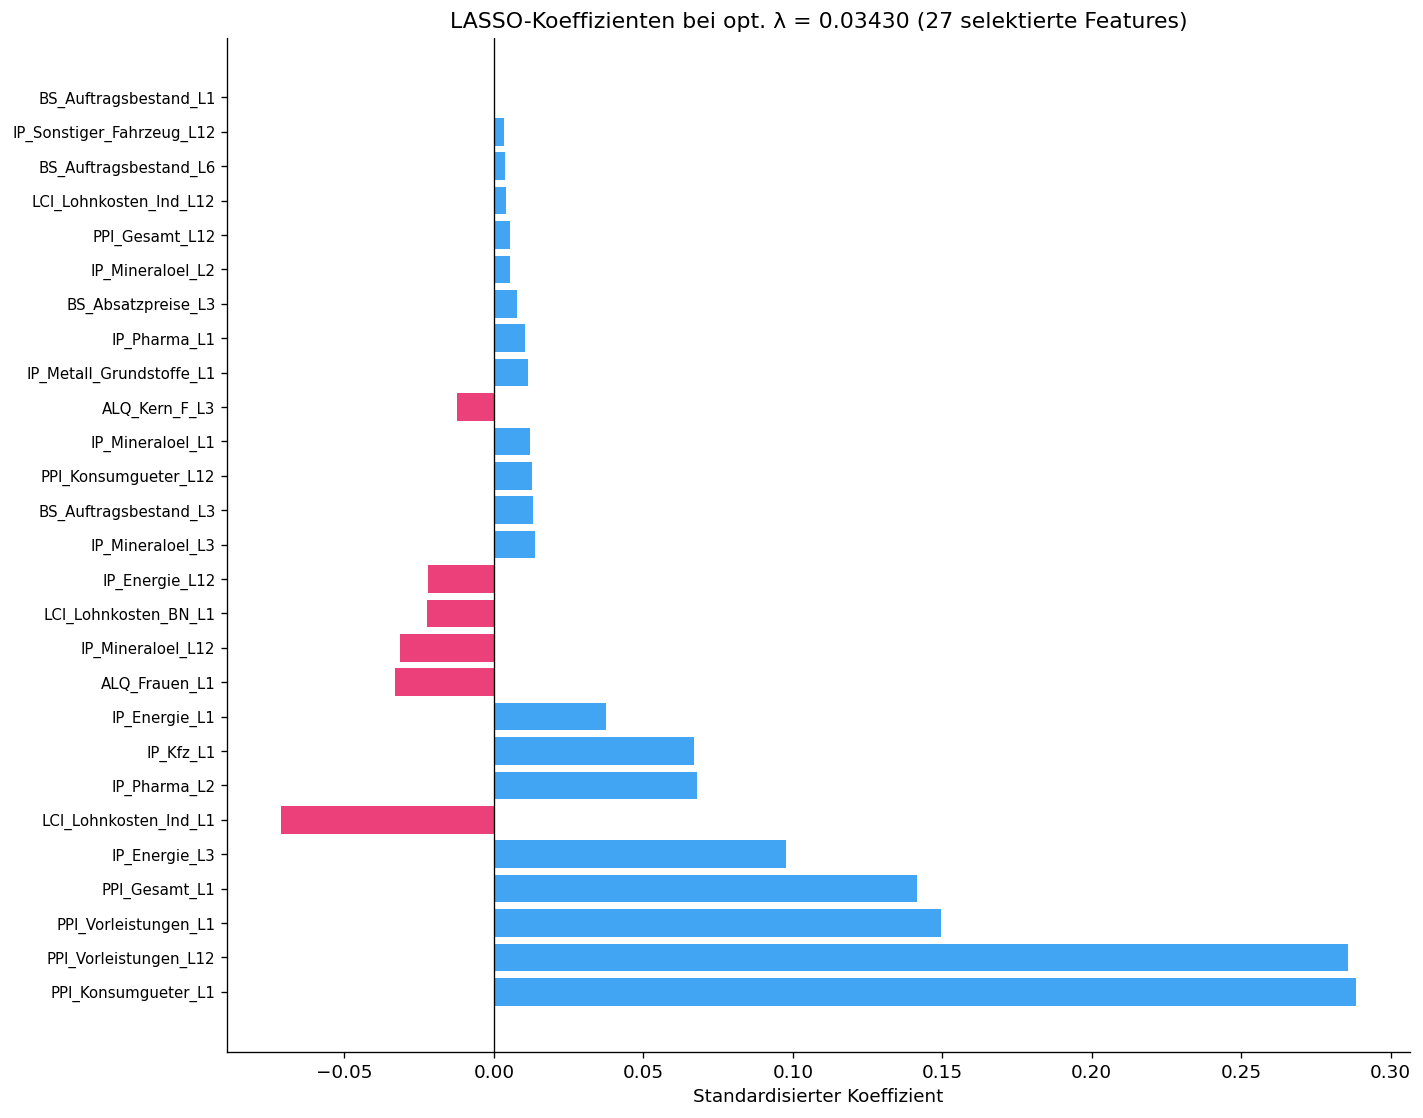


Abbildung gespeichert: fig_08_lasso_selektion.png


In [30]:
# Selektierte Variablen beim optimalen LASSO
lasso_coefs = pd.Series(lasso_cv.coef_, index=X.columns)
selected = lasso_coefs[lasso_coefs != 0].sort_values(key=np.abs, ascending=False)

print(f"LASSO selektiert {len(selected)} von {len(lasso_coefs)} Features:\n")
print(selected.to_string())

# Koeffizientendiagramm
fig, ax = plt.subplots(figsize=(12, max(5, len(selected) * 0.35)))
colors_sel = ["#E91E63" if v < 0 else "#2196F3" for v in selected.values]
ax.barh(range(len(selected)), selected.values, color=colors_sel, alpha=0.85)
ax.set_yticks(range(len(selected)))
ax.set_yticklabels(selected.index, fontsize=9)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"LASSO-Koeffizienten bei opt. λ = {lambda_lasso:.5f} "
             f"({len(selected)} selektierte Features)")
ax.set_xlabel("Standardisierter Koeffizient")
plt.tight_layout()
plt.savefig("results/figures/fig_08_lasso_selektion.png", bbox_inches="tight")
plt.show()
print("\nAbbildung gespeichert: fig_08_lasso_selektion.png")


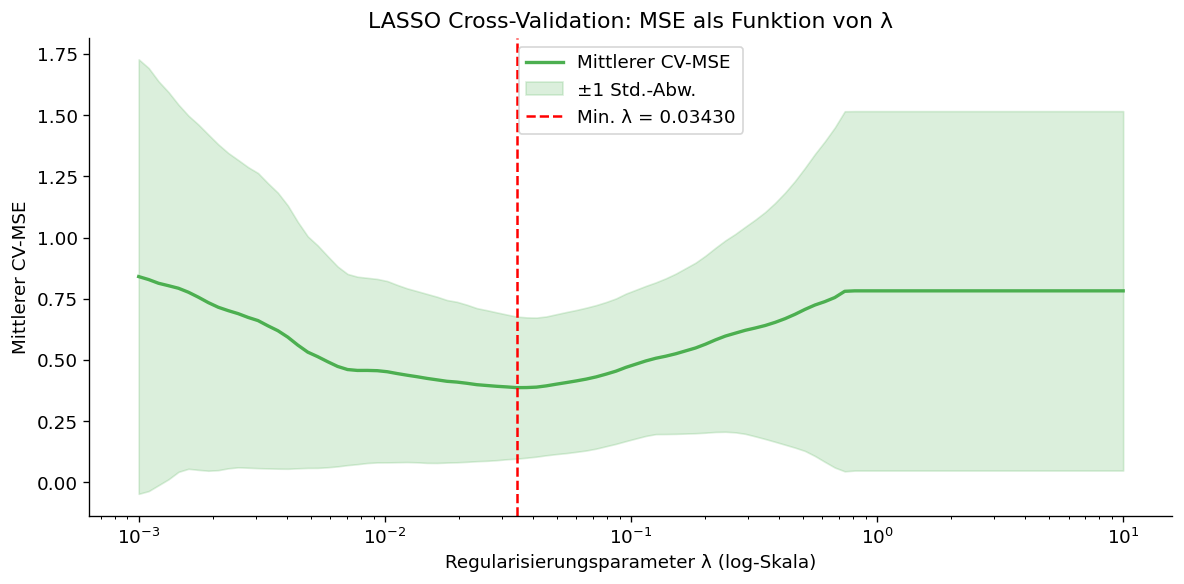

Abbildung gespeichert: fig_09_lasso_cv_path.png


In [31]:
# Cross-Validation MSE als Funktion von λ (für LASSO)
cv_mses = np.mean(lasso_cv.mse_path_, axis=1)
cv_stds = np.std(lasso_cv.mse_path_, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(lasso_cv.alphas_, cv_mses, color="#4CAF50", linewidth=2,
            label="Mittlerer CV-MSE")
ax.fill_between(lasso_cv.alphas_,
                cv_mses - cv_stds,
                cv_mses + cv_stds,
                alpha=0.2, color="#4CAF50", label="±1 Std.-Abw.")
ax.axvline(lambda_lasso, color="red", linestyle="--", linewidth=1.5,
           label=f"Min. λ = {lambda_lasso:.5f}")
ax.set_title("LASSO Cross-Validation: MSE als Funktion von λ")
ax.set_xlabel("Regularisierungsparameter λ (log-Skala)")
ax.set_ylabel("Mittlerer CV-MSE")
ax.legend()
plt.tight_layout()
plt.savefig("results/figures/fig_09_lasso_cv_path.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_09_lasso_cv_path.png")


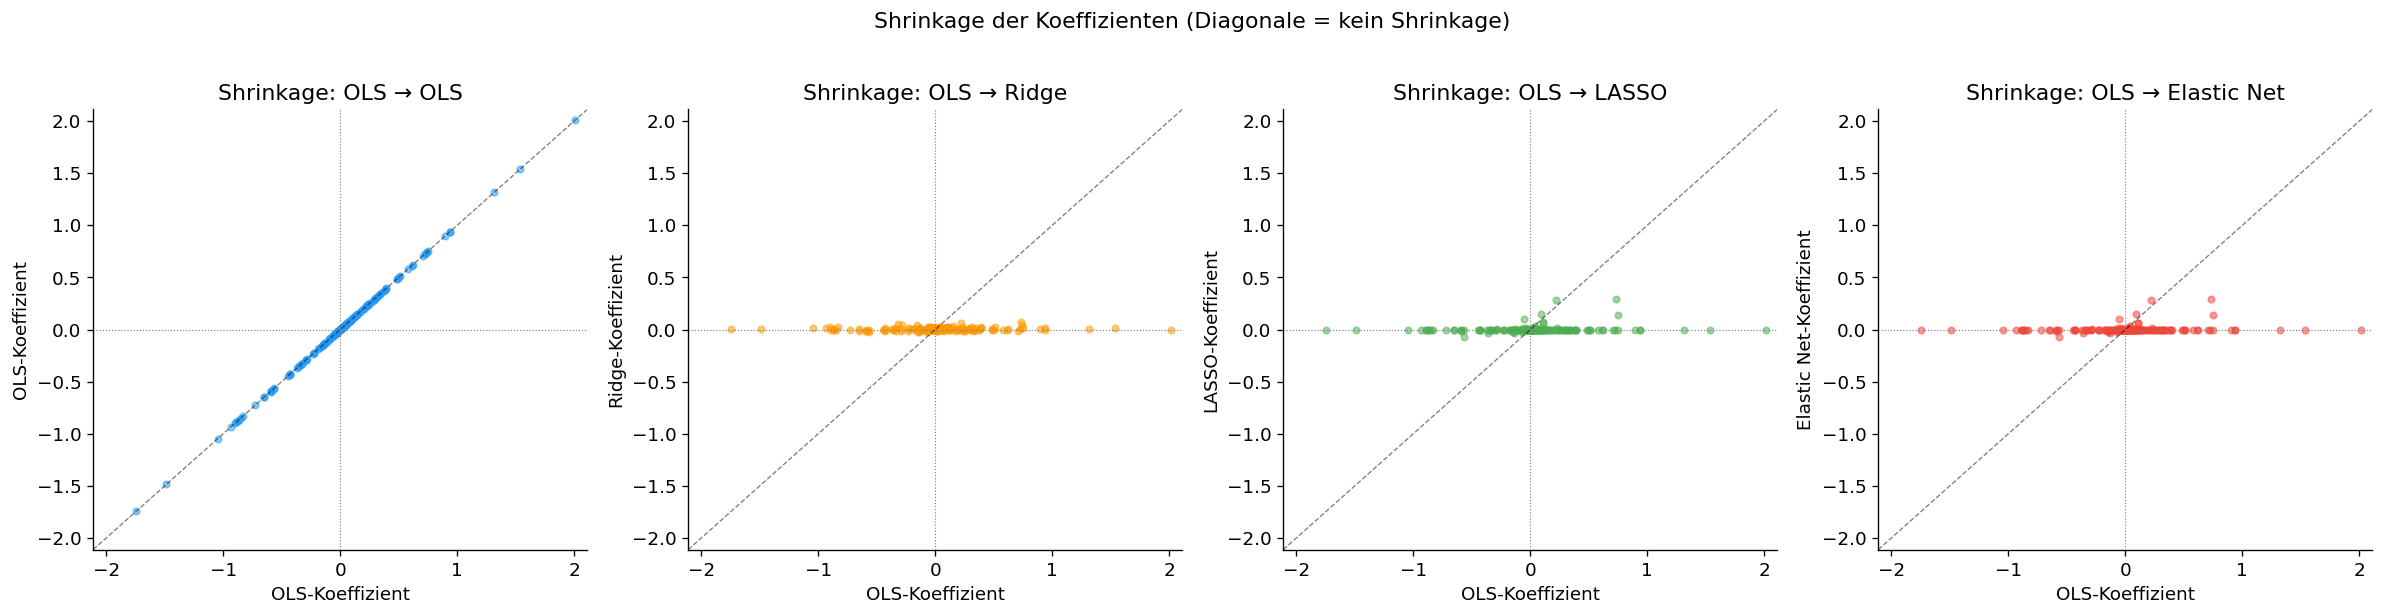

Abbildung gespeichert: fig_10_shrinkage.png


In [ ]:
# Shrinkage-Vergleich: OLS vs. Ridge vs. LASSO vs. Elastic Net
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, coef), col in zip(
    axes,
    [("OLS",         ols.coef_),
     ("Ridge",       ridge_cv.coef_),
     ("LASSO",       lasso_cv.coef_),
     ("Elastic Net", enet_cv.coef_)],
    [COLORS["OLS"], COLORS["Ridge"], COLORS["LASSO"], COLORS["ElasticNet"]],
):
    ax.scatter(ols.coef_, coef, alpha=0.5, s=15, color=col)
    ax.axhline(0, color="gray", linewidth=0.7, linestyle=":")
    ax.axvline(0, color="gray", linewidth=0.7, linestyle=":")
    lim = max(np.abs(ols.coef_).max(), np.abs(coef).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], "k--", linewidth=0.8, alpha=0.5)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_title(f"Shrinkage: OLS → {name}")
    ax.set_xlabel("OLS-Koeffizient")
    ax.set_ylabel(f"{name}-Koeffizient")

plt.suptitle("Shrinkage der Koeffizienten (Diagonale = kein Shrinkage)", y=1.02)
plt.tight_layout()
plt.savefig("results/figures/fig_10_shrinkage.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_10_shrinkage.png")

## 6. Interpretation & Fazit

In [33]:
print("=" * 75)
print("ZUSAMMENFASSUNG DER ERGEBNISSE")
print("=" * 75)
print(f"Datensatz:  {X.shape[0]} Monate, {X.shape[1]} Features")
print(f"Zeitraum:   {y.index[0].strftime('%Y-%m')} – {y.index[-1].strftime('%Y-%m')}")
print(f"Test-Split: {len(y_test)} Monate (chronologisch)")
print()
print(f"{'Modell':<14} {'Test-RMSE':>10} {'RMSE/RW':>9} {'Test-R²':>10} {'Koeff.≠0':>10}")
print("-" * 58)
for name, rmse_val, r2_val, nz in [
    ("Random Walk",  rmse_rw_test,               r2_rw_test,          "-"),
    ("AR(p)",        rmse_ar_test,               r2_ar_test,          str(len(AR_LAGS))),
    ("OLS",          np.sqrt(mse_ols_test),      r2_ols_test,         str(int(np.sum(ols.coef_ != 0)))),
    ("Ridge",        np.sqrt(mse_ridge_test),    r2_ridge_test,       str(len(ridge_cv.coef_))),
    ("LASSO",        np.sqrt(mse_lasso_test),    r2_lasso_test,       str(int(np.sum(lasso_cv.coef_ != 0)))),
    ("Elastic Net",  np.sqrt(mse_enet_test),     r2_enet_test,        str(n_nonzero_enet)),
    ("LASSO+HVPI",   rmse_lasso_plus_test,       r2_lasso_plus_test,  str(n_nonzero_plus)),
]:
    rel = "1.000 (Ref)" if name == "Random Walk" else f"{rmse_val/rmse_rw_test:.3f}"
    print(f"{name:<14} {rmse_val:>10.4f} {rel:>9} {r2_val:>10.4f} {nz:>10}")
print("=" * 75)

best = results["Test RMSE"].astype(float).idxmin()
print(f"\nBestes Modell nach Test-RMSE: {best}")
print()
print("Selektierte Variablengruppen (LASSO):")
for grp, prefix in [
    ("Industrieproduktion", "IP_"),
    ("Business Surveys",    "BS_"),
    ("Produzentenpreise",   "PPI_"),
    ("Arbeitsmarkt",        "ALQ_"),
    ("Lohnkosten",          "LCI_"),
]:
    sel_grp = [c for c in selected.index if prefix in c]
    if sel_grp:
        print(f"  {grp}: {len(sel_grp)} Feature(s) – {sel_grp}")

ZUSAMMENFASSUNG DER ERGEBNISSE
Datensatz:  254 Monate, 165 Features
Zeitraum:   2002-01 – 2024-01
Test-Split: 36 Monate (chronologisch)

Modell          Test-RMSE   RMSE/RW    Test-R²   Koeff.≠0
----------------------------------------------------------
Random Walk        0.9925 1.000 (Ref)     0.9059          -
AR(p)              1.0115     1.019     0.9023          5
OLS                5.0262     5.064    -1.4133        165
Ridge              2.9425     2.965     0.1729        165
LASSO              1.6159     1.628     0.7506         27
Elastic Net        1.6283     1.641     0.7467         26
LASSO+HVPI         1.4425     1.453     0.8012          9

Bestes Modell nach Test-RMSE: Random Walk

Selektierte Variablengruppen (LASSO):
  Industrieproduktion: 12 Feature(s) – ['IP_Energie_L3', 'IP_Pharma_L2', 'IP_Kfz_L1', 'IP_Energie_L1', 'IP_Mineraloel_L12', 'IP_Energie_L12', 'IP_Mineraloel_L3', 'IP_Mineraloel_L1', 'IP_Metall_Grundstoffe_L1', 'IP_Pharma_L1', 'IP_Mineraloel_L2', 'IP_Sonsti

### Interpretation der Ergebnisse

**1. Regularisierung behebt das OLS-Overfitting.** Bei p/n ≈ 0,76 (218 Beobachtungen, 165 Features) und ausgeprägter Multikollinearität (vgl. Konditionszahl in Abschnitt 2b) ist OLS unbrauchbar (Test-R² = −1,41). Ridge, LASSO und Elastic Net stabilisieren die Schätzung deutlich (Test-R² bis 0,75); LASSO erreicht dies mit nur 27 von 165 Variablen und liefert damit eine interpretierbare Selektion.

**2. Kein Makro-Modell schlägt den naiven Random Walk.** Der Random Walk (ŷ_t = y_{t−1}) hat mit RMSE ≈ 0,99 die beste Testgüte; LASSO liegt mit 1,62 rund 63 % darüber. Im robusteren Rolling-Origin-Design rücken die adaptiven Modelle (AR, LASSO+HVPI) bis an den RW heran (0,96 bzw. 0,98), schlagen ihn aber nicht klar — und über alle Horizonte h ∈ {1, 3, 6, 12} bleibt der RW die härteste Messlatte.

**3. Der Makro-Mehrwert über die Persistenz hinaus ist nahe null.** Erst das Modell mit den HVPI-Eigen-Lags (LASSO+HVPI) erreicht das RW-Niveau. Die reinen Makro-Modelle sind strukturell benachteiligt, weil ihnen der mit Abstand beste Einzelprädiktor — die letzte Inflationsrate — per Konstruktion fehlt.

**Einordnung.** Das Ergebnis ist konsistent mit der Literatur zur Inflationsprognose (Atkeson & Ohanian 2001; Stock & Watson 2007): strukturelle bzw. Phillips-Kurven-Modelle schlagen den naiven Benchmark in der Regel nicht. Die Kernaussage der Arbeit ist damit **nicht** „LASSO gewinnt", sondern: Regularisierung ist unverzichtbar, um in einem hochdimensionalen, kollinearen Prädiktorraum überhaupt stabil schätzen zu können — der ökonomische Prognosemehrwert gegenüber der reinen Persistenz bleibt jedoch gering.

**Offene Absicherung (siehe `IMPLEMENTIERUNGSPLAN.md`, Phase B):** Diebold-Mariano-Test auf Signifikanz der Prognoseunterschiede; Verlängerung der Stichprobe um die Disinflation 2024–25; Klärung der h=12-Degeneration (LASSO/EN selektieren dort 0 Variablen).

## 7. Aufbereitung & Export (AP6)

Exportiert Tabellen als LaTeX-Fragmente (`results/*.tex`) und die Datenquellen-Tabelle als CSV + LaTeX für den Anhang. Abbildungen werden bei jedem `savefig`-Aufruf automatisch mit 300 DPI gespeichert (`savefig.dpi = 300` in den rcParams).

In [34]:
# ── Ergebnistabelle → LaTeX ──────────────────────────────────────────────────
# Spaltennamen LaTeX-kompatibel umbenennen
results_export = results.rename(columns={
    "Test R²":            r"Test $R^2$",
    "Nicht-Null-Koeff.":  r"Koeff.$\neq$0",
})

latex_results = results_export.to_latex(
    float_format="%.4f",
    escape=False,
    caption=(
        r"Prognosemodelle im Vergleich: mittlerer RMSE, relatives RMSE (RMSE/RW) "
        r"und $R^2$ im Testset (Nov.~2020--Jan.~2024)."
    ),
    label="tab:ergebnisse",
)
with open("results/results_table.tex", "w") as f:
    f.write(latex_results)
print("results/results_table.tex gespeichert.")
print(latex_results)

results/results_table.tex gespeichert.
\begin{table}
\caption{Prognosemodelle im Vergleich: mittlerer RMSE, relatives RMSE (RMSE/RW) und $R^2$ im Testset (Nov.~2020--Jan.~2024).}
\label{tab:ergebnisse}
\begin{tabular}{lllrrrrl}
\toprule
 & λ & Train MSE & Test MSE & Test RMSE & RMSE/RW & Test $R^2$ & Koeff.$\neq$0 \\
Modell &  &  &  &  &  &  &  \\
\midrule
Random Walk & - & - & 0.9851 & 0.9925 & 1.0000 & 0.9059 & - \\
AR(p) & - & - & 1.0231 & 1.0115 & 1.0191 & 0.9023 & 5 \\
OLS & - & 0.0138 & 25.2626 & 5.0262 & 5.0639 & -1.4133 & 165 \\
Ridge & 403.702 & 0.1598 & 8.6580 & 2.9425 & 2.9646 & 0.1729 & 165 \\
LASSO & 0.03430 & 0.1171 & 2.6111 & 1.6159 & 1.6280 & 0.7506 & 27 \\
Elastic Net & 0.03765 & 0.1190 & 2.6514 & 1.6283 & 1.6405 & 0.7467 & 26 \\
LASSO+HVPI & 0.06579 & - & 2.0808 & 1.4425 & 1.4533 & 0.8012 & 9 \\
\bottomrule
\end{tabular}
\end{table}



In [35]:
# ── Quellen-/Reihen-Tabelle → CSV + LaTeX (Anhang) ───────────────────────────
rows = [
    {"Variable": "HVPI", "Quelle": "ECB SDW",
     "Datensatz": "ICP/M.DE.N.000000.4.INX",
     "Code / Filter": "DE, 000000 (gesamt), Index 2015=100", "Freq.": "M", "SA": "–"},
]
for name, nace in PROD_SECTORS.items():
    rows.append({"Variable": name, "Quelle": "Eurostat",
                 "Datensatz": "sts_inpr_m",
                 "Code / Filter": f"nace_r2={nace}, unit=I15, geo=DE",
                 "Freq.": "M", "SA": "NSA"})
for name, indic in BS_INDICATORS.items():
    rows.append({"Variable": name, "Quelle": "Eurostat",
                 "Datensatz": "ei_bsin_m_r2",
                 "Code / Filter": f"indic={indic}, geo=DE",
                 "Freq.": "M", "SA": "SA"})
for name, nace in PPI_SECTORS.items():
    rows.append({"Variable": name, "Quelle": "Eurostat",
                 "Datensatz": "sts_inppd_m",
                 "Code / Filter": f"nace_r2={nace}, unit=I15, geo=DE",
                 "Freq.": "M", "SA": "NSA"})
for name, grp in UNEMP_GROUPS.items():
    rows.append({"Variable": name, "Quelle": "Eurostat",
                 "Datensatz": "une_rt_m",
                 "Code / Filter": f"sex={grp['sex']}, age={grp['age']}, unit=PC_ACT, geo=DE",
                 "Freq.": "M", "SA": "SA"})
for name, flt in LCI_SERIES.items():
    rows.append({"Variable": name, "Quelle": "Eurostat",
                 "Datensatz": "lc_lci_r2_q",
                 "Code / Filter": (
                     f"nace_r2={flt['nace_r2']}, lcstruct={flt['lcstruct']}, "
                     f"unit=I20, geo=DE; Q→M via ffill"
                 ),
                 "Freq.": "Q→M", "SA": "NSA"})

df_sources = pd.DataFrame(rows)
df_sources.to_csv("results/sources_table.csv", index=False)

latex_sources = df_sources.to_latex(
    index=False, escape=True,
    caption=(
        "Datenquellen: Variable, Quelle, Datensatz-Code und "
        "Saisonbereinigung (SA = saisonbereinigt, NSA = nicht bereinigt)."
    ),
    label="tab:quellen",
)
with open("results/sources_table.tex", "w") as f:
    f.write(latex_sources)

print(f"Quellentabelle: {len(df_sources)} Reihen → results/sources_table.csv + .tex")
print(df_sources.to_string(index=False))

Quellentabelle: 34 Reihen → results/sources_table.csv + .tex
             Variable   Quelle               Datensatz                                                    Code / Filter Freq.  SA
                 HVPI  ECB SDW ICP/M.DE.N.000000.4.INX                              DE, 000000 (gesamt), Index 2015=100     M   –
IP_Verarbeitendes_Gew Eurostat              sts_inpr_m                                      nace_r2=C, unit=I15, geo=DE     M NSA
   IP_Nahrungs_Genuss Eurostat              sts_inpr_m                                nace_r2=C10-C12, unit=I15, geo=DE     M NSA
      IP_Textil_Leder Eurostat              sts_inpr_m                                nace_r2=C13-C15, unit=I15, geo=DE     M NSA
 IP_Holz_Papier_Druck Eurostat              sts_inpr_m                                nace_r2=C16-C18, unit=I15, geo=DE     M NSA
        IP_Mineraloel Eurostat              sts_inpr_m                                    nace_r2=C19, unit=I15, geo=DE     M NSA
            IP_Chemie Eurosta